In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install scikit-plot
!pip install mord
!pip install dmba

In [ ]:
# General Libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
from urllib.request import urlopen
import json
from collections import Counter

# Visualization
import plotly.express as px
import shap

# Statsmodels for Statistical Analysis and Regression
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.regressionplots import plot_leverage_resid2
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from statsmodels.stats import api as sms

# Scikit-learn for Machine Learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, \
                            BaggingClassifier, BaggingRegressor, \
                            GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, \
                            recall_score, f1_score, roc_auc_score, roc_curve, auc, \
                            classification_report, confusion_matrix
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

# DMBA Utility Tools
from dmba import regressionSummary, exhaustive_search, backward_elimination, \
                 forward_selection, stepwise_selection, adjusted_r2_score, \
                 AIC_score, BIC_score, classificationSummary, gainsChart, liftChart, plotDecisionTree

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE, RandomOverSampler

# Optional Additional Libraries
from mord import LogisticIT  # For ordinal regression (from first snippet)

# Warnings Management
warnings.filterwarnings("ignore")

# Pandas Display Settings
pd.set_option('display.max_columns', 50)

# Visualization Aesthetics
plt.style.use('ggplot')


Colab environment detected.


# **MEDICAL INSURANCE DATA**

In [ ]:
#Getting the Dataset
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Group_Project_704/Medical_Insurance_1.csv')

Encoding the categorical variables for easiness of analysis.

In [ ]:
# For 'sex'
print("Before encoding 'sex':")
print(data['sex'].unique())
data['sex'] = data['sex'].astype('category').cat.codes
print("After encoding 'sex':")
print(data['sex'].unique())

# For 'smoker'
print("\nBefore encoding 'smoker':")
print(data['smoker'].unique())
data['smoker'] = data['smoker'].astype('category').cat.codes
print("After encoding 'smoker':")
print(data['smoker'].unique())

# For 'region'
print("\nBefore encoding 'region':")
print(data['region'].unique())
data['region'] = data['region'].astype('category').cat.codes
print("After encoding 'region':")
print(data['region'].unique())


# Split data into features (X) and target (y)
X = data.drop('charges', axis=1)
X=sm.add_constant(X)
y = data['charges']

# Split into training and testing sets
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

Before encoding 'sex':
['male' 'female']
After encoding 'sex':
[1 0]

Before encoding 'smoker':
['no' 'yes']
After encoding 'smoker':
[0 1]

Before encoding 'region':
['northeast' 'southeast' 'northwest' 'southwest']
After encoding 'region':
[0 2 1 3]


# Cleaning

Using variance inflation factors in order to filter out highly intercorr

---



In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.stats.api as sms

def multicol(X, threshold=15):
    while True:
        # Calculate VIF for each feature
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

        #highest VIF
        high_vif = vif_data[vif_data['VIF'] > threshold].sort_values(by='VIF', ascending=False)

        #break loop
        if high_vif.empty:
            break

        drop_feature = high_vif.iloc[0]['feature']
        X = X.drop(columns=[drop_feature])
        print(f"Dropped {drop_feature} with VIF {high_vif.iloc[0]['VIF']}")

    return X

X = multicol(X)

X

Dropped const with VIF 45.61559606491998


,age,sex,bmi,smoker,region,children
0,21.000000,1,25.745000,0,0,2
1,36.976978,0,25.744165,1,2,3
2,18.000000,1,30.030000,0,2,1
3,37.000000,1,30.676891,0,0,3
4,58.000000,1,32.010000,0,2,1
...,...,...,...,...,...,...
3625,48.820767,0,41.426984,0,1,4
3626,38.661977,0,26.202557,0,2,2
3627,56.000000,1,40.300000,0,3,0
3628,48.061207,0,34.930624,0,2,1


In [ ]:
model = sm.OLS(y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                charges   R-squared (uncentered):                   0.875
Model:                            OLS   Adj. R-squared (uncentered):              0.875
Method:                 Least Squares   F-statistic:                              4241.
Date:                Tue, 03 Dec 2024   Prob (F-statistic):                        0.00
Time:                        02:29:03   Log-Likelihood:                         -36667.
No. Observations:                3630   AIC:                                  7.335e+04
Df Residuals:                    3624   BIC:                                  7.338e+04
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
age          188.2702      7.548     24.944      0.000     173.472     203.069
sex          796.2889    199.105      3.999      0.000     405.920    1186.658
bmi           72.9005     11.562      6.305      0.000      50.233      95.568
smoker      2.271e+04    277.566     81.830      0.000    2.22e+04    2.33e+04
region      -930.3008     89.192    -10.430      0.000   -1105.173    -755.428
children     361.6963     58.031      6.233      0.000     247.920     475.472
==============================================================================
Omnibus:                      840.049   Durbin-Watson:                   2.026
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2282.286
Skew:                           1.223   Prob(JB):                         0.00
Kurtosis:                       6.018   Cond. No.                         145.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

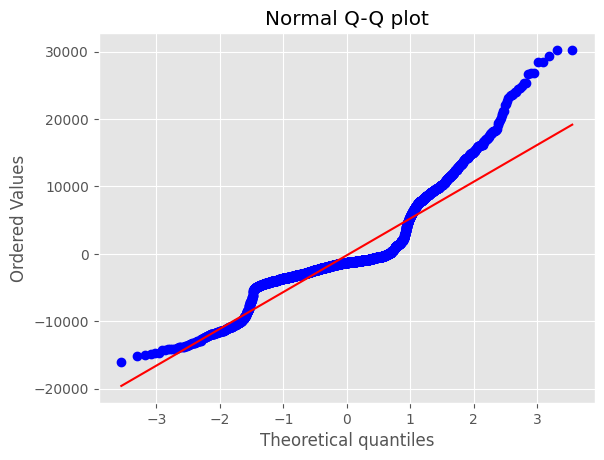

Shapiro-Wilk test p-value: 1.6228103269571343e-49


In [ ]:
residuals=results.resid
#Non-normality
# Check for Normality of Residuals
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()

# Shapiro-Wilk test for normality
_, p_value_shapiro = stats.shapiro(residuals)
print(f"Shapiro-Wilk test p-value: {p_value_shapiro}")

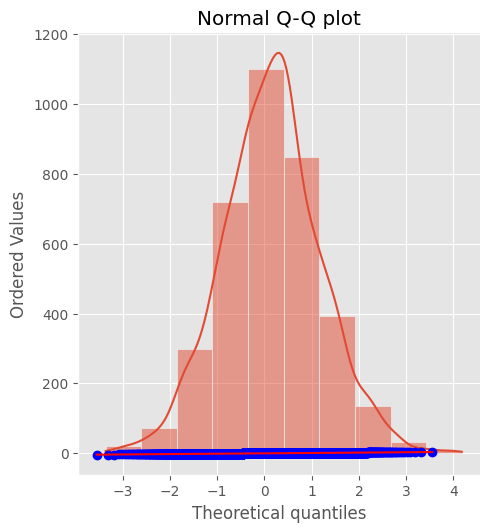

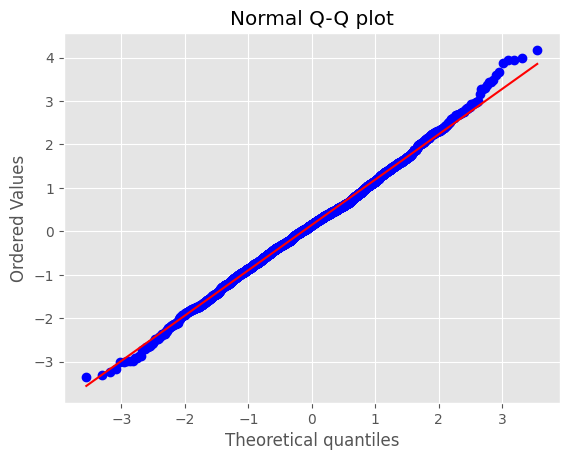

Shapiro-Wilk test p-value (Box-Cox transformed): 4.576839658116572e-05


In [ ]:
#Boxcox transformation
from scipy.stats import boxcox

# Apply Box-Cox transformation to the response variable
y_transformed, lambda_val = boxcox(y)

# Fit the OLS model with the transformed response variable
model_boxcox = sm.OLS(y_transformed, X)
results_boxcox = model_boxcox.fit()

# Get the residuals of the transformed model
residuals_boxcox = results_boxcox.resid

# Visualize the distribution of the residuals
sns.displot(residuals_boxcox, bins=10, kde=True, kind="hist")
stats.probplot(residuals_boxcox, dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()

stats.probplot(residuals_boxcox, dist="norm", plot=plt)
plt.title("Normal Q-Q plot")
plt.show()

# Perform Shapiro-Wilk test for normality
_, p_value_shapiro_boxcox = stats.shapiro(residuals_boxcox)
print(f"Shapiro-Wilk test p-value (Box-Cox transformed): {p_value_shapiro_boxcox}")

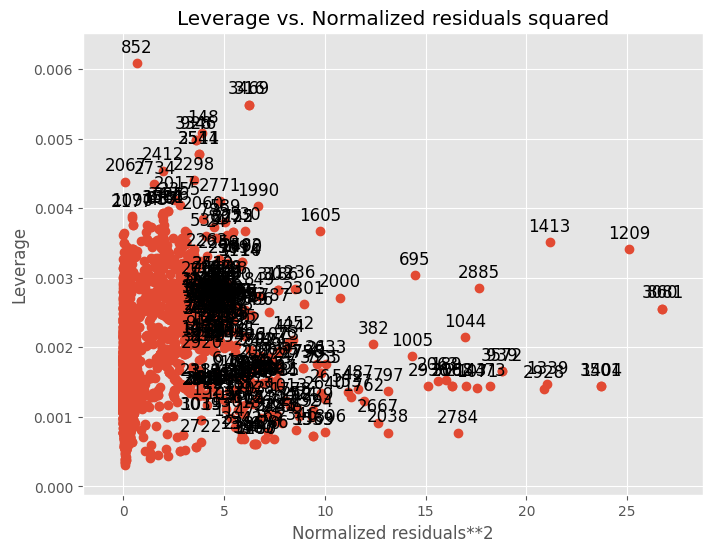

In [ ]:
from statsmodels.graphics.regressionplots import plot_leverage_resid2

fig, ax = plt.subplots(figsize=(8,6))
fig = plot_leverage_resid2(results, ax = ax)


In [ ]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                charges   R-squared (uncentered):                   0.875
Model:                            OLS   Adj. R-squared (uncentered):              0.875
Method:                 Least Squares   F-statistic:                              4241.
Date:                Tue, 03 Dec 2024   Prob (F-statistic):                        0.00
Time:                        02:29:13   Log-Likelihood:                         -36667.
No. Observations:                3630   AIC:                                  7.335e+04
Df Residuals:                    3624   BIC:                                  7.338e+04
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
age          188.2702      7.548     24.944      0.000     173.472     203.069
sex          796.2889    199.105      3.999      0.000     405.920    1186.658
bmi           72.9005     11.562      6.305      0.000      50.233      95.568
smoker      2.271e+04    277.566     81.830      0.000    2.22e+04    2.33e+04
region      -930.3008     89.192    -10.430      0.000   -1105.173    -755.428
children     361.6963     58.031      6.233      0.000     247.920     475.472
==============================================================================
Omnibus:                      840.049   Durbin-Watson:                   2.026
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2282.286
Skew:                           1.223   Prob(JB):                         0.00
Kurtosis:                       6.018   Cond. No.                         145.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Model

Using the code from lecture to run bagging, boosting, and random forests, and check which one works best

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.25, random_state=7)

# Bagging: Decide the parameters for the new Decision Tree with ensemble
dthealthreg_bag=RandomForestRegressor(max_features=6, random_state=23) # Bagging is special case of RF, when we use all features (6 in this case).

# Random forest: Decide the parameters for the new Decision Tree with ensemble
dthealthreg_RF=RandomForestRegressor(max_features=2, random_state=23)

# Boosting: Decide the parameters for the new Decision Tree with ensemble
dthealthreg_boost=GradientBoostingRegressor(n_estimators=500, learning_rate=0.01, random_state=23) # Learning rate shrinks the contribution of each tree by learning_rate.

# Fit the bagging model on training data
# Since we are using the training portion of the data, we are now "training" our model.
dthealthreg_bag.fit(X_train, Y_train)

# Fit the random forest model on training data
# Since we are using the training portion of the data, we are now "training" our model.
dthealthreg_RF.fit(X_train, Y_train)

# Fit the boosting model on training data
# Since we are using the training portion of the data, we are now "training" our model.
dthealthreg_boost.fit(X_train, Y_train)

# Now, get the predicted values and evaluate the training of the new decision tree models:
DTbag_predictions_tr=dthealthreg_bag.predict(X_train) # predictions for training set

# Now, get the predicted values and evaluate the training of the new decision tree models:
DTRF_predictions_tr=dthealthreg_RF.predict(X_train) # predictions for training set

# Now, get the predicted values and evaluate the training of the new decision tree models:
DTboost_predictions_tr=dthealthreg_boost.predict(X_train) # predictions for training set

# How good is this prediction of bagging in training?
regressionSummary(Y_train, DTbag_predictions_tr)

# How good is this prediction of random forest in training?
regressionSummary(Y_train, DTRF_predictions_tr)

# How good is this prediction of random forest in training?
regressionSummary(Y_train,DTboost_predictions_tr)


Regression statistics

                      Mean Error (ME) : -24.7903
       Root Mean Squared Error (RMSE) : 1280.8828
            Mean Absolute Error (MAE) : 546.4032
          Mean Percentage Error (MPE) : -3.0419
Mean Absolute Percentage Error (MAPE) : 5.4212

Regression statistics

                      Mean Error (ME) : 17.3593
       Root Mean Squared Error (RMSE) : 1243.7413
            Mean Absolute Error (MAE) : 566.8342
          Mean Percentage Error (MPE) : -3.1174
Mean Absolute Percentage Error (MAPE) : 5.6225

Regression statistics

                      Mean Error (ME) : 0.0000
       Root Mean Squared Error (RMSE) : 3968.5380
            Mean Absolute Error (MAE) : 2267.1662
          Mean Percentage Error (MPE) : -14.0664
Mean Absolute Percentage Error (MAPE) : 23.9650


Based on the regression statistics above, RF and bagging models are the best, with RF being slightly better due to a slightly lower RMSE. Therefore, we use this model for the graphs below

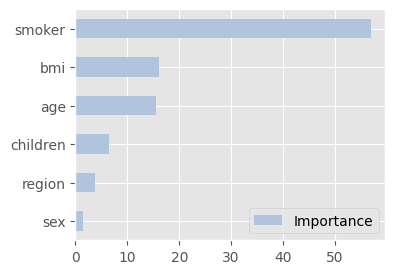

In [ ]:
Importance = pd.DataFrame({'Importance':dthealthreg_RF.feature_importances_*100}, \
                          index=["age", "sex", "bmi", "smoker", "region", "children"])
Importance.sort_values('Importance', axis=0, ascending=True).plot(kind='barh', color='lightsteelblue', ) # kind='barh' : Horizontal bar
plt.gcf().set_size_inches(4, 3)

There's a steady rise in charges associated with increase in age. Sex has a slight effect, with men paying about $1000 more in overall average

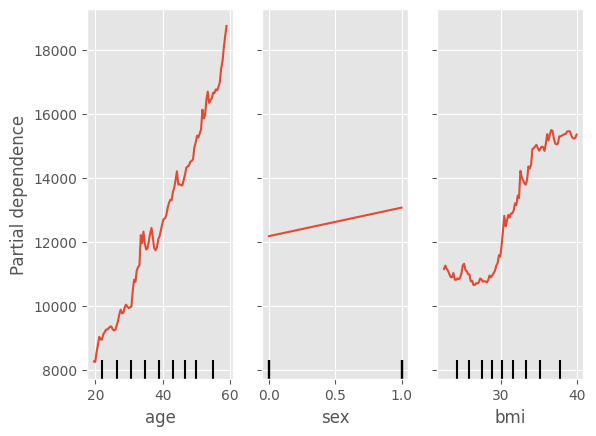

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
features = [0, 1, 2]
PartialDependenceDisplay.from_estimator(dthealthreg_RF, X_train, features)

BMI shows a very interesting, immediate increase around BMI = 30. This could indicate some kind of threshold in insurance systems that increases charges at that point. Being a smoker has by far the largest increase, with 10000 dollars for non smokers and more than 30000 dollars for smokers, tripling the charges.

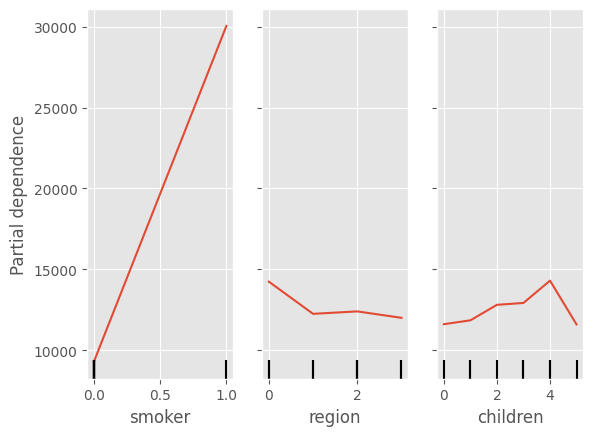

In [ ]:
features = [3, 4, 5]
PartialDependenceDisplay.from_estimator(dthealthreg_RF, X_train, features)

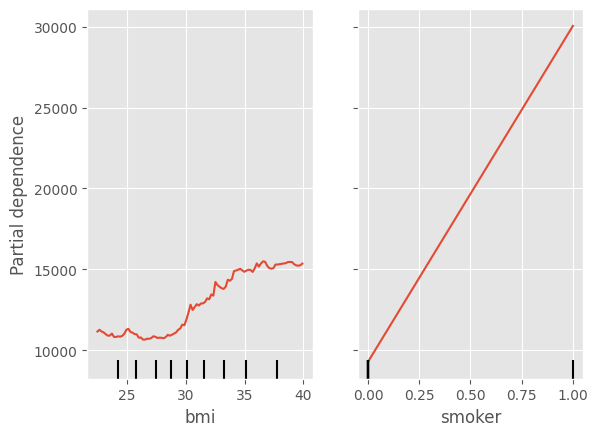

In [ ]:
features = [2, 3]
PartialDependenceDisplay.from_estimator(dthealthreg_RF, X_train, features)

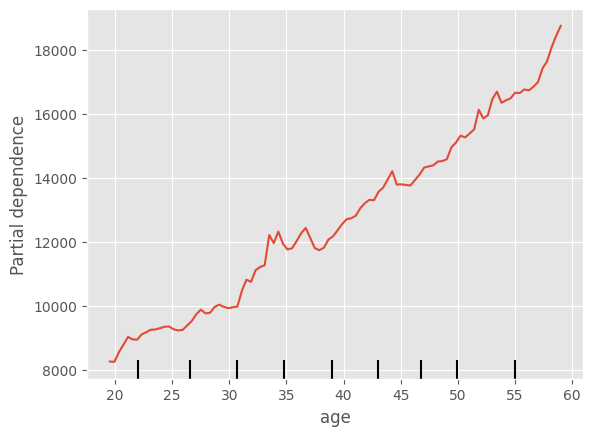

In [ ]:
features = [0]
PartialDependenceDisplay.from_estimator(dthealthreg_RF, X_train, features)

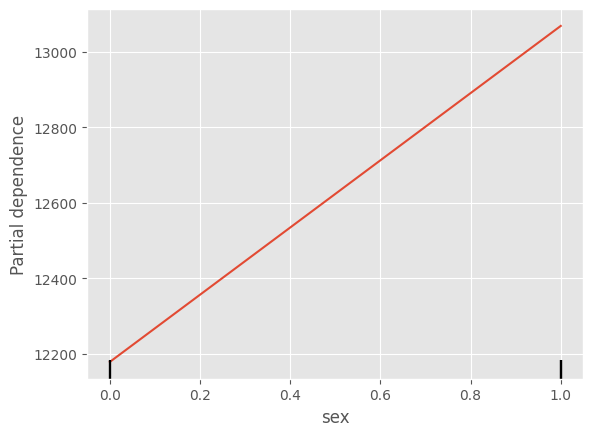

In [ ]:
features = [1]
PartialDependenceDisplay.from_estimator(dthealthreg_RF, X_train, features)

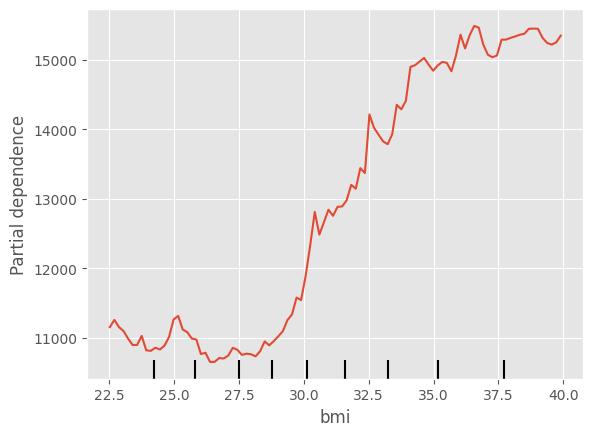

In [ ]:
features = [2]
PartialDependenceDisplay.from_estimator(dthealthreg_RF, X_train, features)

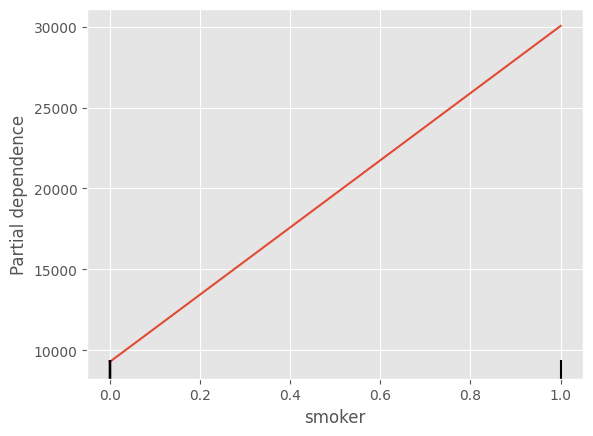

In [ ]:
features = [3]
PartialDependenceDisplay.from_estimator(dthealthreg_RF, X_train, features)

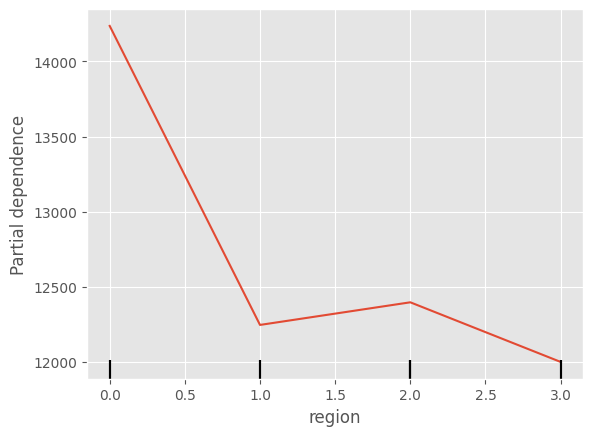

In [ ]:
features = [4]
PartialDependenceDisplay.from_estimator(dthealthreg_RF, X_train, features)

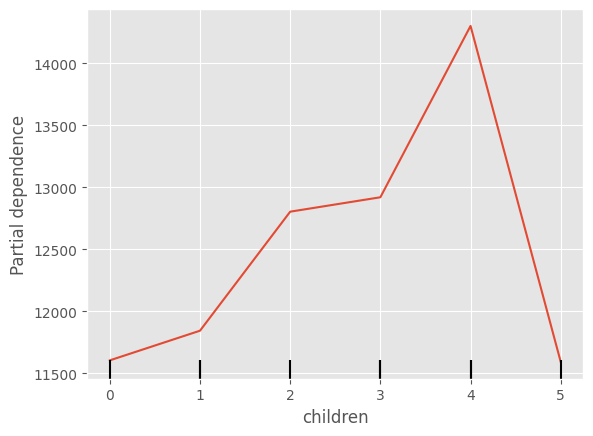

In [ ]:
features = [5]
PartialDependenceDisplay.from_estimator(dthealthreg_RF, X_train, features)

These show some unintuitive results. Northeast accounts for the highest charges (more than 15000 on average). Also, having 4 children apparently raises the charges significantly, while having 5 children has a lower average charge.

# Visualization

As seen previously, while smoking usually brings up the average charges, smoking while also having a higher than 30 bmi spikes the charges considerably.

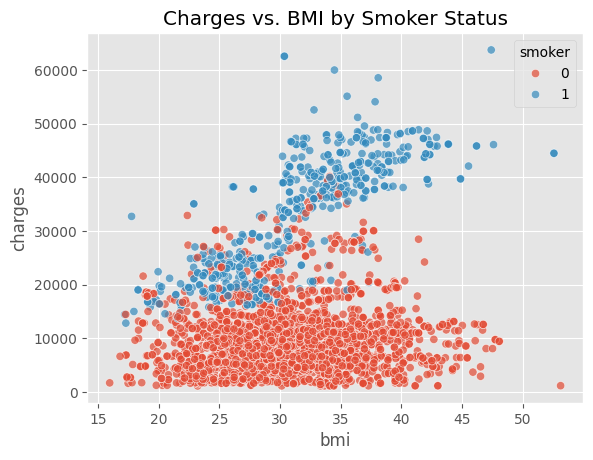

In [ ]:
#USEFUL

sns.scatterplot(data=data, x='bmi', y='charges', hue='smoker', alpha=0.7)
plt.title('Charges vs. BMI by Smoker Status')
plt.show()


Based on the previous results, we put bmi 30 as the last lower limit, and we can see the steep increase as compared to non smokers in the same region.

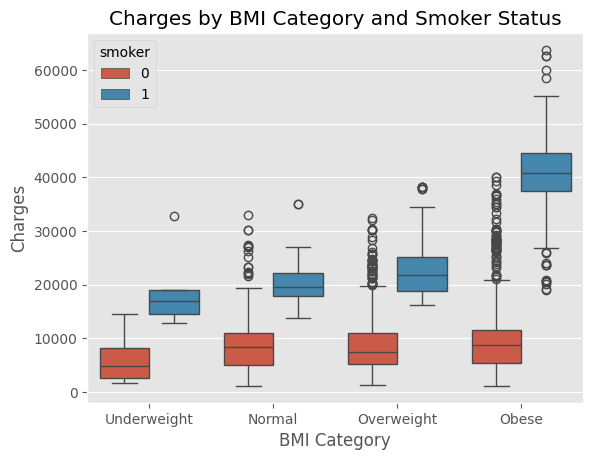

In [ ]:
data['bmi_category'] = pd.cut(data['bmi'], bins=[0, 18.5, 25, 30, np.inf], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

sns.boxplot(data=data, x='bmi_category', y='charges', hue='smoker')
plt.title('Charges by BMI Category and Smoker Status')
plt.xlabel('BMI Category')
plt.ylabel('Charges')
plt.show()

A grouped analysis shows the combinations that have the highest and lowest charges. As printed below, the highest charges on average were recorded for **female smokers in the southeast**, **aged 45 with 2 children**, and around **37 bmi**. The lowest was for the same region, for **male non-smokers with 4 children** (surprisingly since having 4 children was usually correlated with higher charges), **age 27 and bmi 28**.

In [ ]:
import plotly.express as px

# Aggregate the data to calculate mean charges, mean age, and mean BMI for each group
grouped_data = data.groupby(['region', 'children', 'smoker', 'sex'], as_index=False).agg({'charges': 'mean', 'age': 'mean', 'bmi': 'mean'})

# Find the bar with the highest charges
highest_charge_row = grouped_data.loc[grouped_data['charges'].idxmax()]
lowest_charge_row = grouped_data.loc[grouped_data['charges'].idxmin()]

print("Bar with Highest Charges:")
print(highest_charge_row)

print("\nBar with Lowest Charges:")
print(lowest_charge_row)

# Create a bar plot with BMI represented by color
fig = px.bar(
    grouped_data,
    x='children',
    y='charges',
    color='bmi',  # Use BMI for the color scale
    facet_row='smoker',
    facet_col='region',
    title='Average Charges by Number of Children, Smoker Status, Region, Sex, and BMI',
    facet_col_wrap=2,  # Wrap columns for better visualization if many panels
)

# Update axis labels and colorbar for readability
fig.update_layout(
    xaxis_title="Number of Children",
    yaxis_title="Average Charges",
    coloraxis_colorbar=dict(title="Average BMI"),  # Add a title for the color legend
    title_font_size=16
)

# Show the plot
fig.show()


Bar with Highest Charges:
region          2.000000
children        2.000000
smoker          1.000000
sex             0.000000
charges     41152.697189
age            45.864722
bmi            37.309652
Name: 50, dtype: float64

Bar with Lowest Charges:
region         2.000000
children       4.000000
smoker         0.000000
sex            1.000000
charges     5462.200240
age           26.857609
bmi           28.609094
Name: 57, dtype: float64


# **CREDIT SCORE**

In [ ]:
# # Loading the dataset
df_selected_countries = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Group_Project_704/credit_score_personal.csv')
df_selected_countries

,Age,Gender,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,City,State,Country,Previous Defaults,Marital Status Change,Risk Rating
0,49,Male,PhD,Divorced,72799.0,688.0,45713.0,Business,Unemployed,19,Poor,0.154313,120228.0,0.0,Port Elizabeth,AS,Cyprus,2.0,2,Low
1,57,Female,Bachelor's,Widowed,NaN,690.0,33835.0,Auto,Employed,6,Fair,0.148920,55849.0,0.0,North Catherine,OH,Turkmenistan,3.0,2,Medium
2,21,Non-binary,Master's,Single,55687.0,600.0,36623.0,Home,Employed,8,Fair,0.362398,180700.0,3.0,South Scott,OK,Luxembourg,3.0,2,Medium
3,59,Male,Bachelor's,Single,26508.0,622.0,26541.0,Personal,Unemployed,2,Excellent,0.454964,157319.0,3.0,Robinhaven,PR,Uganda,4.0,2,Medium
4,25,Non-binary,Bachelor's,Widowed,49427.0,766.0,36528.0,Personal,Unemployed,10,Fair,0.143242,287140.0,NaN,New Heather,IL,Namibia,3.0,1,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,23,Non-binary,Bachelor's,Widowed,48088.0,609.0,26187.0,Home,Self-employed,2,Fair,0.317633,NaN,4.0,Susanstad,TN,Djibouti,2.0,0,Low
14996,56,Male,PhD,Single,107193.0,700.0,35111.0,Auto,Self-employed,10,Fair,0.155126,79102.0,NaN,Port Heather,WA,Congo,0.0,0,Medium
14997,29,Non-binary,PhD,Married,46250.0,642.0,44369.0,Home,Unemployed,19,Excellent,0.593999,196930.0,4.0,South Morganchester,LA,Palau,2.0,1,High
14998,53,Non-binary,PhD,Divorced,40180.0,638.0,32752.0,Home,Self-employed,12,Excellent,0.478035,276060.0,NaN,Port Wayne,AK,Rwanda,0.0,2,High


In [ ]:
df_selected_countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    15000 non-null  int64  
 1   Gender                 15000 non-null  object 
 2   Education Level        15000 non-null  object 
 3   Marital Status         15000 non-null  object 
 4   Income                 12750 non-null  float64
 5   Credit Score           12750 non-null  float64
 6   Loan Amount            12750 non-null  float64
 7   Loan Purpose           15000 non-null  object 
 8   Employment Status      15000 non-null  object 
 9   Years at Current Job   15000 non-null  int64  
 10  Payment History        15000 non-null  object 
 11  Debt-to-Income Ratio   15000 non-null  float64
 12  Assets Value           12750 non-null  float64
 13  Number of Dependents   12750 non-null  float64
 14  City                   15000 non-null  object 
 15  St

In [ ]:
num_cols = df_selected_countries.select_dtypes(include = {'int64','float64'}).columns
cat_cols = df_selected_countries.select_dtypes(include = {'object'}).columns

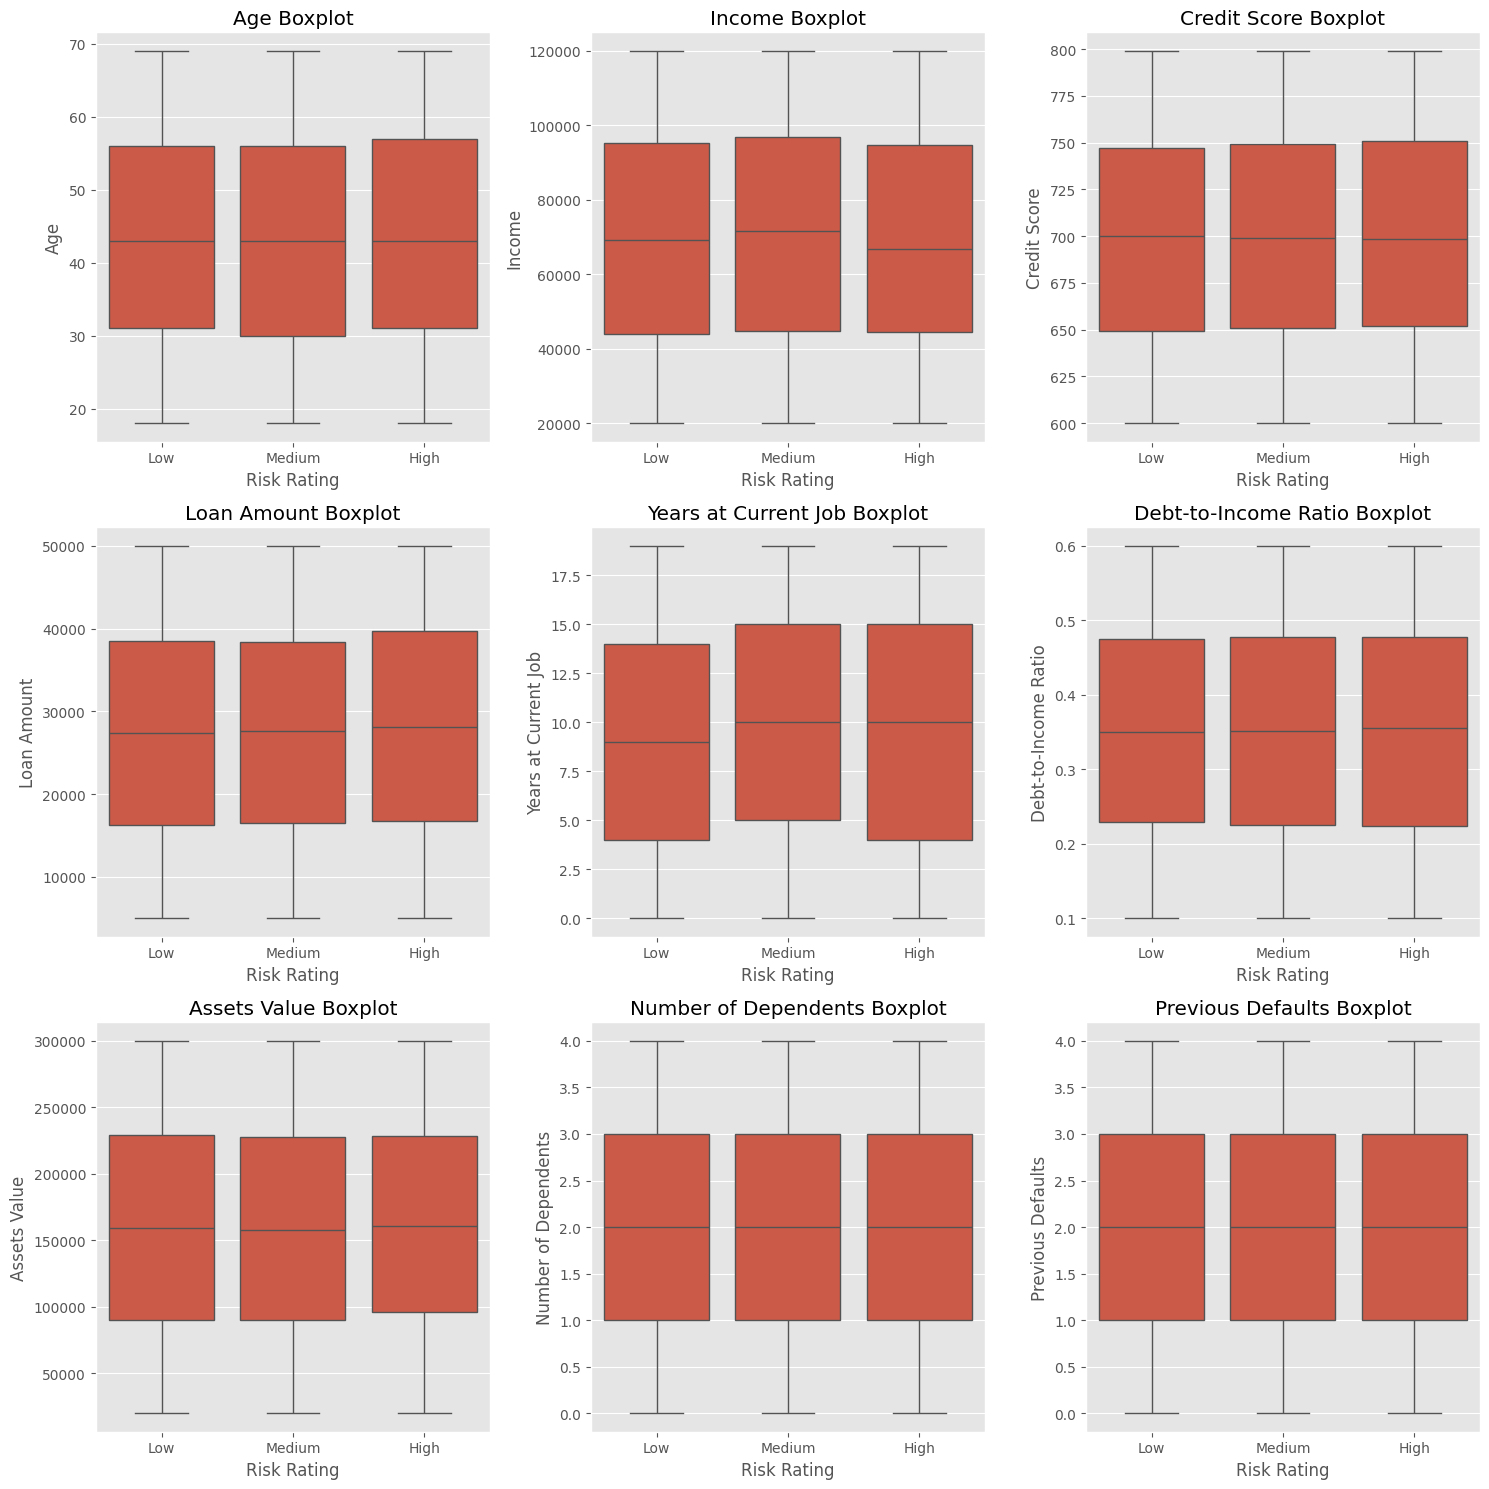

In [ ]:
f, ax = plt.subplots(3,3, figsize=(15, 15))
ax = ax.flatten()

for index, cols in enumerate(num_cols[0:9]):
    sns.boxplot(data=df_selected_countries, x ='Risk Rating' , y= cols, ax = ax[index])
    ax[index].set_title(f'{cols} Boxplot')

plt.tight_layout()
plt.show()

Imputing the missing data with mode after grouping by appropriate features. For example Income depends on Country and the Education level, so impute it by the mode after grouping it by those features.

## Data cleaning and preparation

In [ ]:
na_counts = df_selected_countries.isna().sum()
na_counts

,0
Age,0
Gender,0
Education Level,0
Marital Status,0
Income,2250
Credit Score,2250
Loan Amount,2250
Loan Purpose,0
Employment Status,0
Years at Current Job,0


In [ ]:
df_selected_countries.drop(columns=['Credit Score'], inplace=True)

df_selected_countries['Income'] = df_selected_countries.groupby(['Country', 'Education Level'])['Income'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.mean())
)

df_selected_countries['Loan Amount'] = df_selected_countries.groupby(['Country', 'Loan Purpose'])['Loan Amount'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.mean())
)

df_selected_countries['Assets Value'] = df_selected_countries.groupby(['Country', 'Education Level', 'Employment Status'])['Assets Value'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.mean())
)

df_selected_countries['Number of Dependents'] = df_selected_countries.groupby(['Marital Status'])['Number of Dependents'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.mean())
)

df_selected_countries['Previous Defaults'] = df_selected_countries.groupby(['Country', 'Risk Rating'])['Previous Defaults'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.mean())
)

df_selected_countries.dropna(inplace=True)

na_counts = df_selected_countries.isna().sum()
na_counts

,0
Age,0
Gender,0
Education Level,0
Marital Status,0
Income,0
Loan Amount,0
Loan Purpose,0
Employment Status,0
Years at Current Job,0
Payment History,0


In [ ]:
na_counts = df_selected_countries.isna().sum()
na_counts

,0
Age,0
Gender,0
Education Level,0
Marital Status,0
Income,0
Loan Amount,0
Loan Purpose,0
Employment Status,0
Years at Current Job,0
Payment History,0


In [ ]:
df_selected_countries = df_selected_countries.drop(['City', 'State', 'Country', 'Marital Status Change', 'Years at Current Job', 'Gender'], axis=1, errors='ignore')

df_selected_countries.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14966 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   14966 non-null  int64  
 1   Education Level       14966 non-null  object 
 2   Marital Status        14966 non-null  object 
 3   Income                14966 non-null  float64
 4   Loan Amount           14966 non-null  float64
 5   Loan Purpose          14966 non-null  object 
 6   Employment Status     14966 non-null  object 
 7   Payment History       14966 non-null  object 
 8   Debt-to-Income Ratio  14966 non-null  float64
 9   Assets Value          14966 non-null  float64
 10  Number of Dependents  14966 non-null  float64
 11  Previous Defaults     14966 non-null  float64
 12  Risk Rating           14966 non-null  object 
dtypes: float64(6), int64(1), object(6)
memory usage: 1.6+ MB


In [ ]:
for col in df_selected_countries.select_dtypes(include='object').columns:
  print(f"Unique values for column '{col}':")
  print(df_selected_countries[col].unique())
  print("-" * 20)

Unique values for column 'Education Level':
['PhD' "Bachelor's" "Master's" 'High School']
--------------------
Unique values for column 'Marital Status':
['Divorced' 'Widowed' 'Single' 'Married']
--------------------
Unique values for column 'Loan Purpose':
['Business' 'Auto' 'Home' 'Personal']
--------------------
Unique values for column 'Employment Status':
['Unemployed' 'Employed' 'Self-employed']
--------------------
Unique values for column 'Payment History':
['Poor' 'Fair' 'Excellent' 'Good']
--------------------
Unique values for column 'Risk Rating':
['Low' 'Medium' 'High']
--------------------


###Encoding the categorical variables

In [ ]:
credit_mix_mapping = {
    'PhD' : 3,
    "Bachelor's" : 2,
    "Master's" : 1,
    'High School' : 0
}

df_selected_countries['Education Level'] = df_selected_countries['Education Level'].map(credit_mix_mapping)

credit_mix_mapping = {
    'Unemployed' : 0,
    "Employed" : 2,
    "Self-employed" : 1
}

df_selected_countries['Employment Status'] = df_selected_countries['Employment Status'].map(credit_mix_mapping)

credit_mix_mapping = {
    'Poor' : 0,
    "Fair" : 2,
    "Excellent" : 3,
    "Good" : 1
}

df_selected_countries['Payment History'] = df_selected_countries['Payment History'].map(credit_mix_mapping)

credit_mix_mapping = {
    'Low' : 0,
    "Medium" : 1,
    "High" : 2
}

df_selected_countries['Risk Rating'] = df_selected_countries['Risk Rating'].map(credit_mix_mapping)

label=LabelEncoder()
# df_selected_countries['Gender']=label.fit_transform(df_selected_countries['Gender'])
df_selected_countries['Marital Status']=label.fit_transform(df_selected_countries['Marital Status'])
df_selected_countries['Loan Purpose']=label.fit_transform(df_selected_countries['Loan Purpose'])

In [ ]:
df_selected_countries.head()

,Age,Education Level,Marital Status,Income,Loan Amount,Loan Purpose,Employment Status,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,Previous Defaults,Risk Rating
0,49,3,0,72799.0,45713.0,1,0,0,0.154313,120228.0,0.0,2.0,0
1,57,2,3,39941.0,33835.0,0,2,2,0.148920,55849.0,0.0,3.0,1
2,21,1,2,55687.0,36623.0,2,2,2,0.362398,180700.0,3.0,3.0,1
3,59,2,2,26508.0,26541.0,3,0,3,0.454964,157319.0,3.0,4.0,1
4,25,2,3,49427.0,36528.0,3,0,2,0.143242,287140.0,4.0,3.0,0


##Model Building

In [ ]:
y = df_selected_countries['Risk Rating']
X = df_selected_countries.drop(columns=['Risk Rating'])

One of the classes in Risk rating is undersampled which was making the models very biased hence using SMOTE technique to balance out the class distribution

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(Counter(y_resampled))

Counter({0: 8977, 1: 8977, 2: 8977})


* Plotting a mutual dependency plot which quantifies how much knowing one variable reduces uncertainty about the other.

In [ ]:
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_resampled, y_resampled)

for i, score in enumerate(mi_scores):
    print(f"Feature '{X_resampled.columns[i]}': Mutual Information Score = {score}")

Feature 'Age': Mutual Information Score = 0.007062974362094909
Feature 'Education Level': Mutual Information Score = 0.009385893921008748
Feature 'Marital Status': Mutual Information Score = 0.015198969285958874
Feature 'Income': Mutual Information Score = 0.0253798847338369
Feature 'Loan Amount': Mutual Information Score = 0.026398238085773462
Feature 'Loan Purpose': Mutual Information Score = 0.017636433738678736
Feature 'Employment Status': Mutual Information Score = 0.01077115834965614
Feature 'Payment History': Mutual Information Score = 0.01937462210697216
Feature 'Debt-to-Income Ratio': Mutual Information Score = 0.02371470070407966
Feature 'Assets Value': Mutual Information Score = 0.02270013645455382
Feature 'Number of Dependents': Mutual Information Score = 0.20484592437692206
Feature 'Previous Defaults': Mutual Information Score = 0.21185133053190275


In [ ]:
import plotly.graph_objects as go
sorted_mi_scores = sorted(zip(X_resampled.columns, mi_scores), key=lambda x: x[1], reverse=True)
sorted_columns = [x[0] for x in sorted_mi_scores]
sorted_scores = [x[1] for x in sorted_mi_scores]

colorscale = 'Viridis'

fig = go.Figure(data=[go.Bar(x=sorted_columns, y=sorted_scores, marker=dict(color=sorted_scores, colorbar=dict(title='Mutual Information Score', len=0.5, y=0.2)))])

fig.update_layout(title='Mutual Information Scores for Each Feature',
                  xaxis_title='Features',
                  yaxis_title='Mutual Information Score')

fig.show()

Even before modeling, the mutual Information Score graphs gives out a good idea about what features affect the credit score risk rating more

Trained 3 classifying models - Logistic regression, Decision Tree and Random forest.

###Logistic Regression

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

train_X, valid_X, train_y, valid_y = train_test_split(X_scaled, y_resampled, test_size=0.25, random_state=1)

lreg = LogisticRegression(solver='liblinear', class_weight='balanced')
lreg.fit(train_X, train_y)

LogisticRegression(class_weight='balanced', solver='liblinear')

In [ ]:
lreg_predictions_tr=lreg.predict(train_X)
lreg_predictions_tr[:5]

array([2, 0, 0, 2, 2])

In [ ]:
classificationSummary(train_y, lreg_predictions_tr)

Confusion Matrix (Accuracy 0.4288)

       Prediction
Actual    0    1    2
     0 3916  668 2139
     1 2768  794 3175
     2 2076  712 3950


In [ ]:
print("Classification Report:\n",classification_report(train_y, lreg_predictions_tr))

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.58      0.51      6723
           1       0.37      0.12      0.18      6737
           2       0.43      0.59      0.49      6738

    accuracy                           0.43     20198
   macro avg       0.41      0.43      0.39     20198
weighted avg       0.41      0.43      0.39     20198



In [ ]:
# Feature importance
data = df_selected_countries.copy()
coefficients = pd.DataFrame({
    'Feature': data.drop(columns=['Risk Rating']).columns,
    'Coefficient': lreg.coef_[0],
    'Odds Ratio': np.exp(lreg.coef_[0])
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

                 Feature  Coefficient  Odds Ratio
6      Employment Status     0.260800    1.297968
7        Payment History     0.245566    1.278344
5           Loan Purpose     0.213935    1.238542
2         Marital Status     0.197877    1.218812
1        Education Level     0.196268    1.216853
0                    Age     0.043205    1.044152
11     Previous Defaults     0.006935    1.006959
8   Debt-to-Income Ratio     0.006215    1.006234
3                 Income     0.006110    1.006129
10  Number of Dependents    -0.015288    0.984828
4            Loan Amount    -0.020141    0.980060
9           Assets Value    -0.020567    0.979643


###Decision Tree

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.25, random_state= 2)

In [ ]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

# Train the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred = dt_model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.54
Confusion Matrix:
 [[1222  740  285]
 [ 652  982  636]
 [ 230  557 1429]]
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.54      0.56      2247
           1       0.43      0.43      0.43      2270
           2       0.61      0.64      0.63      2216

    accuracy                           0.54      6733
   macro avg       0.54      0.54      0.54      6733
weighted avg       0.54      0.54      0.54      6733



Feature Importance:
                  Feature  Importance
11     Previous Defaults    0.175240
3                 Income    0.134337
9           Assets Value    0.130316
4            Loan Amount    0.125138
8   Debt-to-Income Ratio    0.113790
0                    Age    0.085807
10  Number of Dependents    0.078127
7        Payment History    0.040069
5           Loan Purpose    0.032218
2         Marital Status    0.031718
1        Education Level    0.030580
6      Employment Status    0.022661


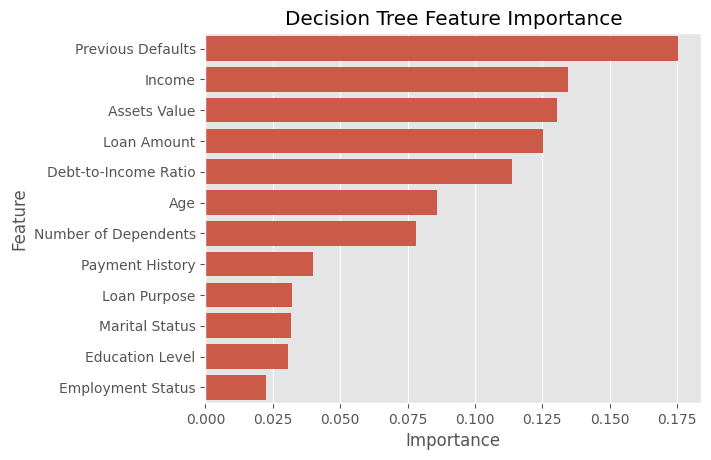

In [ ]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:\n", feature_importance)

# Plot feature importance
import seaborn as sns

sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Decision Tree Feature Importance')
plt.show()

###Random forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.67
Confusion Matrix:
 [[1898  283   66]
 [ 897  850  523]
 [ 326  150 1740]]
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.84      0.71      2247
           1       0.66      0.37      0.48      2270
           2       0.75      0.79      0.77      2216

    accuracy                           0.67      6733
   macro avg       0.67      0.67      0.65      6733
weighted avg       0.67      0.67      0.65      6733



Feature Importance:
                  Feature  Importance
9           Assets Value    0.125500
3                 Income    0.123670
4            Loan Amount    0.121211
8   Debt-to-Income Ratio    0.118631
11     Previous Defaults    0.110582
0                    Age    0.101350
10  Number of Dependents    0.099156
7        Payment History    0.044399
5           Loan Purpose    0.041827
1        Education Level    0.041627
2         Marital Status    0.040855
6      Employment Status    0.031192


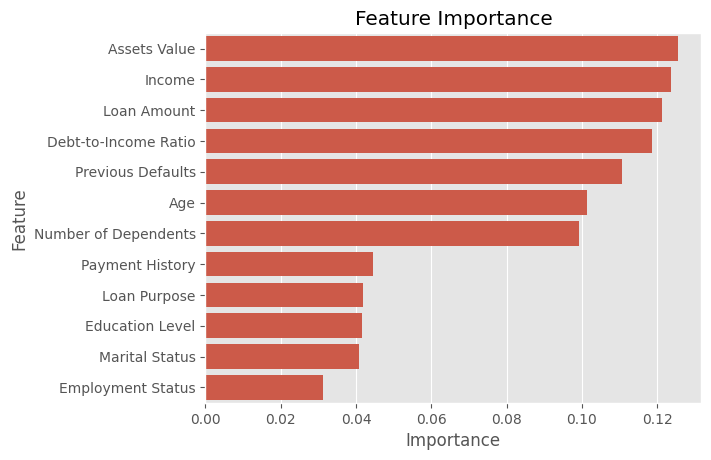

In [ ]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:\n", feature_importance)

import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()

Out of the 3 classifying models, Random Forest performs the best with around 67% accuracy.

The main idea is to get the importance of features in predicting the risk rating which are mostly consistent across the models.

Plotting the partial dependency plots to understand whether the impact of each feature on the target variable aligns with expectations and to identify any interesting thresholds or significant changes in behavior.

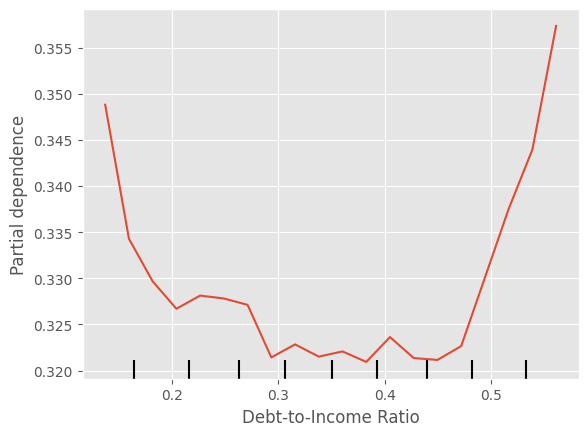

In [ ]:
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_test,
    features=['Debt-to-Income Ratio'],
    target=0,
    kind='average',
    grid_resolution=20
)
plt.show()

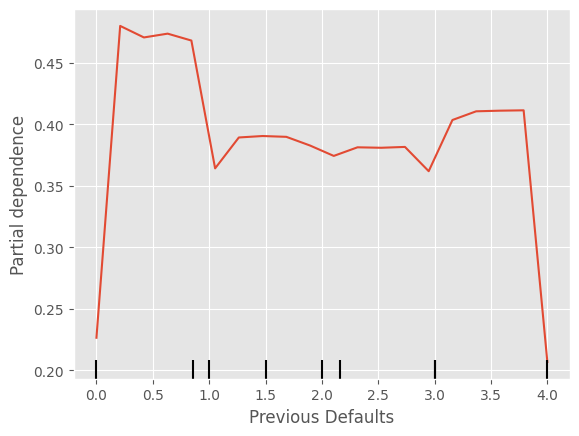

In [ ]:
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_test,
    features=['Previous Defaults'],
    target=2,
    kind='average',
    grid_resolution=20
)
plt.show()

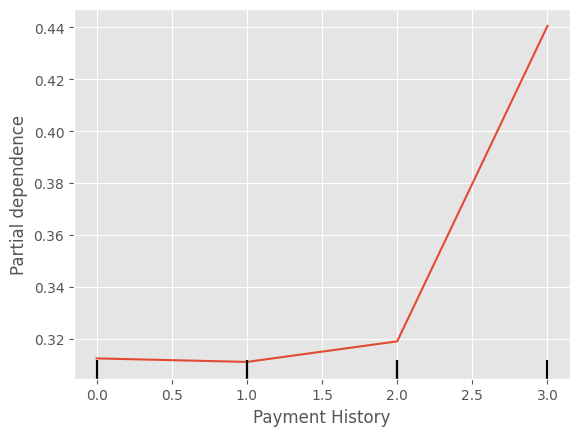

In [ ]:
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_test,
    features=['Payment History'],
    target=0,
    kind='average',
    grid_resolution=20
)
plt.show()

# **FINANCIAL RISK ASSESSMENT**

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Group_Project_704/credit_score_financial.csv')
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

As observed, this dataset contains numerous features that indicate a person’s financial health. Our focus will be on identifying the most impactful features and understanding their influence.

##Data cleaning

Upon examining the dataset, I noticed the presence of significant amounts of irrelevant or ‘garbage’ data that lacked meaningful value. Retaining such data could hinder the performance of our models. Therefore, each feature was carefully reviewed, and such irrelevant values and anomalies were addressed appropriately.

This step can be time-consuming as it involves grouping by the customer and calculating the mode to impute missing or invalid values.

In [ ]:
#Annual Income
df_train['Annual_Income'] = df_train['Annual_Income'].astype(str).str.replace('_', '', regex=False)
df_train['Annual_Income'] = pd.to_numeric(df_train['Annual_Income'], errors='coerce')

In [ ]:
#Occupation
def fill_occupation_with_mode(group):
    mode = group[group != '_______'].mode()
    if not mode.empty:
        group[group == '_______'] = mode[0]
    return group

df_train['Occupation'] = df_train.groupby('Customer_ID')['Occupation'].transform(fill_occupation_with_mode)

In [ ]:
# Num_Bank_Accounts
def replace_high_num_accounts(group):
    mode = group[group <= 10].mode()
    if not mode.empty:
        mode_value = mode[0]
        group[group > 10] = mode_value
    return group

df_train['Num_Bank_Accounts'] = df_train.groupby('Customer_ID')['Num_Bank_Accounts'].transform(replace_high_num_accounts)

In [ ]:
# Num_Credit_Card
def replace_high_credit_cards(group):
    mode = group[group <= 30].mode()
    if not mode.empty:
        mode_value = mode[0]
        group[group > 30] = mode_value
    return group

df_train['Num_Credit_Card'] = df_train.groupby('Customer_ID')['Num_Credit_Card'].transform(replace_high_credit_cards)

In [ ]:
# Interest_Rate
def replace_high_interest_rate(group):
    mode = group[group <= 15].mode()
    if not mode.empty:
        mode_value = mode[0]
        group[group > 15] = mode_value
    return group

df_train['Interest_Rate'] = df_train.groupby('Customer_ID')['Interest_Rate'].transform(replace_high_interest_rate)

In [ ]:
# Num_of_Loan
df_train['Num_of_Loan'] = df_train['Num_of_Loan'].astype(str).str.replace('_', '', regex=False)
df_train['Num_of_Loan'] = pd.to_numeric(df_train['Num_of_Loan'], errors='coerce')

def replace_invalid_loans(group):
    mode = group[(group >= 0) & (group <= 9)].mode()
    if not mode.empty:
        mode_value = mode[0]
        group[(group < 0) | (group > 9)] = mode_value
    return group

df_train['Num_of_Loan'] = df_train.groupby('Customer_ID')['Num_of_Loan'].transform(replace_invalid_loans)

In [ ]:
# Delay_from_due_date
df_train['Delay_from_due_date'] = df_train['Delay_from_due_date'].apply(lambda x: 0 if x < 0 else x)

In [ ]:
# Num_of_Delayed_Payment
df_train['Num_of_Delayed_Payment'] = df_train['Num_of_Delayed_Payment'].astype(str).str.replace('_', '', regex=False)
df_train['Num_of_Delayed_Payment'] = pd.to_numeric(df_train['Num_of_Delayed_Payment'], errors='coerce')

def replace_invalid_delayed_payments(group):
    mode = group[(group >= 0) & (group <= 30)].mode()
    if not mode.empty:
        mode_value = mode[0]
        group[(group.isna()) | (group < 0) | (group > 30)] = mode_value
    return group

df_train['Num_of_Delayed_Payment'] = df_train.groupby('Customer_ID')['Num_of_Delayed_Payment'].transform(replace_invalid_delayed_payments)

In [ ]:
# Credit_Mix
def replace_hyphen_with_mode(group):
    mode = group[group != '_'].mode()
    if not mode.empty:
        mode_value = mode[0]
        group[group == '_'] = mode_value
    return group

df_train['Credit_Mix'] = df_train.groupby('Customer_ID')['Credit_Mix'].transform(replace_hyphen_with_mode)

In [ ]:
# Outstanding_Debt
df_train['Outstanding_Debt'] = df_train['Outstanding_Debt'].astype(str).str.rstrip('_')
df_train['Outstanding_Debt'] = pd.to_numeric(df_train['Outstanding_Debt'], errors='coerce')

In [ ]:
# Credit_History_Age
def fill_credit_history_age_with_mode(group):
    mode = group.mode()
    if not mode.empty:
        mode_value = mode[0]
        group.fillna(mode_value, inplace=True)
    return group

df_train['Credit_History_Age'] = df_train.groupby('Customer_ID')['Credit_History_Age'].transform(fill_credit_history_age_with_mode)

def parse_years_and_months(age):
    if isinstance(age, str):
        age_parts = age.split(' Years and ')
        years = int(age_parts[0]) if 'Years' in age else 0
        months_str = age_parts[1].split(' Months')[0] if 'Months' in age_parts[1] else '0'
        months = int(months_str)
        total_months = years * 12 + months
        return total_months
    else:
        return 0

df_train['Credit_History_Age_Months'] = df_train['Credit_History_Age'].apply(parse_years_and_months)

In [ ]:
# Payment_of_Min_Amount
def impute_nm_with_mode(group):
    mode_value = group[group != 'NM'].mode()
    if not mode_value.empty:
        group[group == 'NM'] = mode_value[0]
    return group

df_train['Payment_of_Min_Amount'] = df_train.groupby('Customer_ID')['Payment_of_Min_Amount'].transform(impute_nm_with_mode)

In [ ]:
# Total_EMI_per_month
df_train = df_train[df_train['Total_EMI_per_month'] <= 2000]

# Amount_invested_monthly
df_train['Amount_invested_monthly'] = df_train['Amount_invested_monthly'].astype(str).str.replace('__', '', regex=False)
df_train['Amount_invested_monthly'] = pd.to_numeric(df_train['Amount_invested_monthly'], errors='coerce')

# Payment_Behaviour
def impute_invalid_with_mode(group):
    mode_value = group[group != '!@9#%8'].mode()
    if not mode_value.empty:
        group[group == '!@9#%8'] = mode_value[0]
    return group

df_train['Payment_Behaviour'] = df_train.groupby('Customer_ID')['Payment_Behaviour'].transform(impute_invalid_with_mode)

# Monthly_Balance
df_train = df_train[df_train['Monthly_Balance'] != '__-333333333333333333333333333__']
df_train = df_train[df_train['Monthly_Balance'].notna() & (df_train['Monthly_Balance'] != '')]
df_train['Monthly_Balance'] = pd.to_numeric(df_train['Monthly_Balance'], errors='coerce')

Box plots were created for all numerical features to identify and address the presence of outliers.

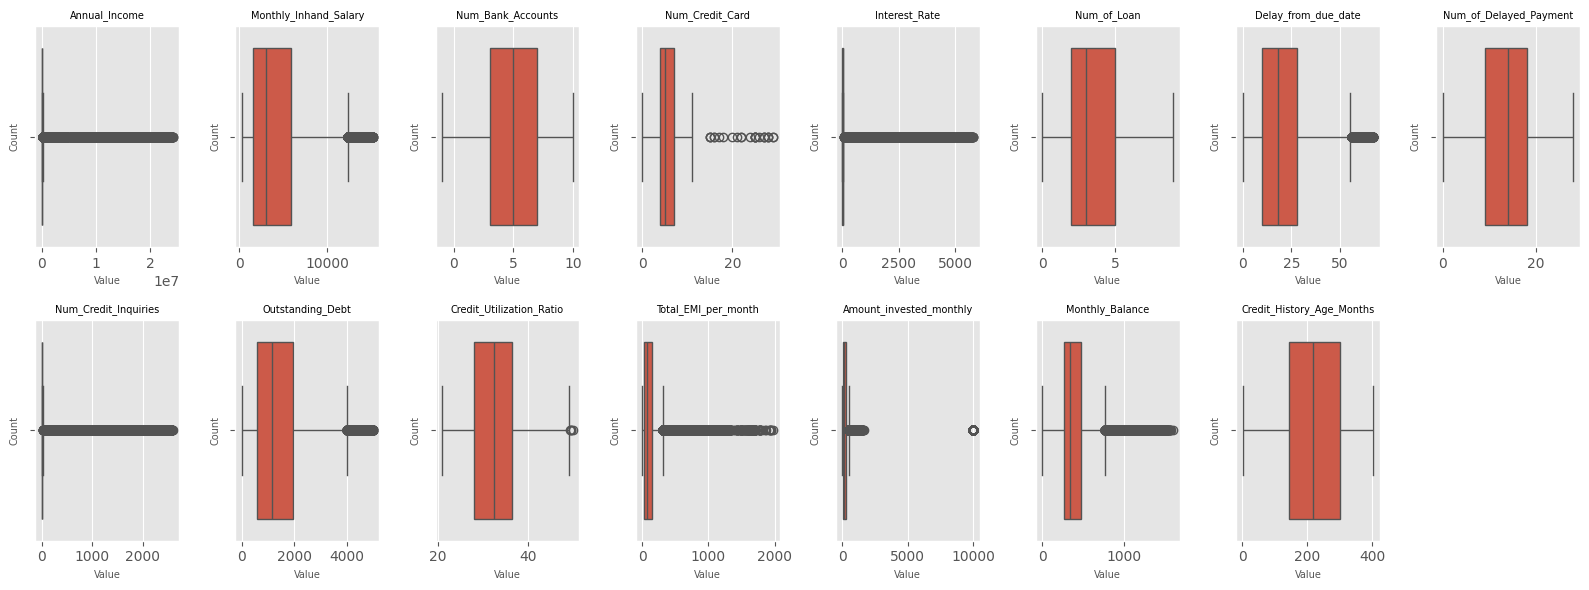

In [ ]:
numeric_columns = df_train.select_dtypes(include=['int64', 'float64']).columns

num_columns = 8
num_rows = (len(numeric_columns) + num_columns - 1) // num_columns

fig, axes = plt.subplots(num_rows, num_columns, figsize=(16, 6))

axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.boxplot(x=df_train[column], ax=axes[i])
    axes[i].set_title(column, fontsize=7)
    axes[i].set_xlabel('Value', fontsize=7)
    axes[i].set_ylabel('Count', fontsize=7)

for j in range(len(numeric_columns), num_columns*num_rows):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df_train = df_train[df_train['Num_Credit_Card'] <= 10]
df_train = df_train[df_train['Delay_from_due_date'] <= 60]
df_train = df_train[df_train['Total_EMI_per_month'] <= 200]
df_train = df_train[df_train['Interest_Rate'] <= 50]

df_train = df_train.dropna(subset=['Amount_invested_monthly'])
df_train = df_train.dropna(subset=['Num_Credit_Inquiries'])
df_train = df_train.dropna(subset=['Num_Credit_Inquiries'])

def make_boxplot(df, column, ax):
    sns.boxplot(x="Credit_Score", y=column, data=df, ax=ax, width=0.8, palette="Set2")
    plt.xticks(rotation=90)
    # add the five number summary to the plot
    plt.title(column, fontdict={"fontsize": 10})
    plt.xticks(rotation=0)

import matplotlib
matplotlib.rc(("xtick", "ytick", "text"), c="k")
matplotlib.rc("figure", dpi=80)

In [ ]:
def plot_boxplot_num_cols(df):
    fig = plt.figure(figsize=(18, 14), dpi=300)
    numb_columns = df.select_dtypes(include="number").columns
    for column in numb_columns:
        ax = fig.add_subplot(5, 4, list(numb_columns).index(column)+1)
        make_boxplot(df, column, ax)
        plt.tight_layout(pad=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# Removing Annual_Income outliers
Q1 = df_train['Annual_Income'].quantile(0.25)
Q3 = df_train['Annual_Income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_no_outliers = df_train[(df_train['Annual_Income'] >= lower_bound) & (df_train['Annual_Income'] <= upper_bound)]

print(f"Removed {len(df_train) - len(df_no_outliers)} outliers.")

Removed 3562 outliers.


In [ ]:
# Removing Amount_invested_monthly outliers
Q1 = df_no_outliers['Amount_invested_monthly'].quantile(0.25)
Q3 = df_no_outliers['Amount_invested_monthly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_no_outliers = df_no_outliers[(df_no_outliers['Amount_invested_monthly'] >= lower_bound) & (df_no_outliers['Amount_invested_monthly'] <= upper_bound)]

df_train = df_no_outliers

Box plots were used to analyze the trends of each feature in relation to changes in credit scores.

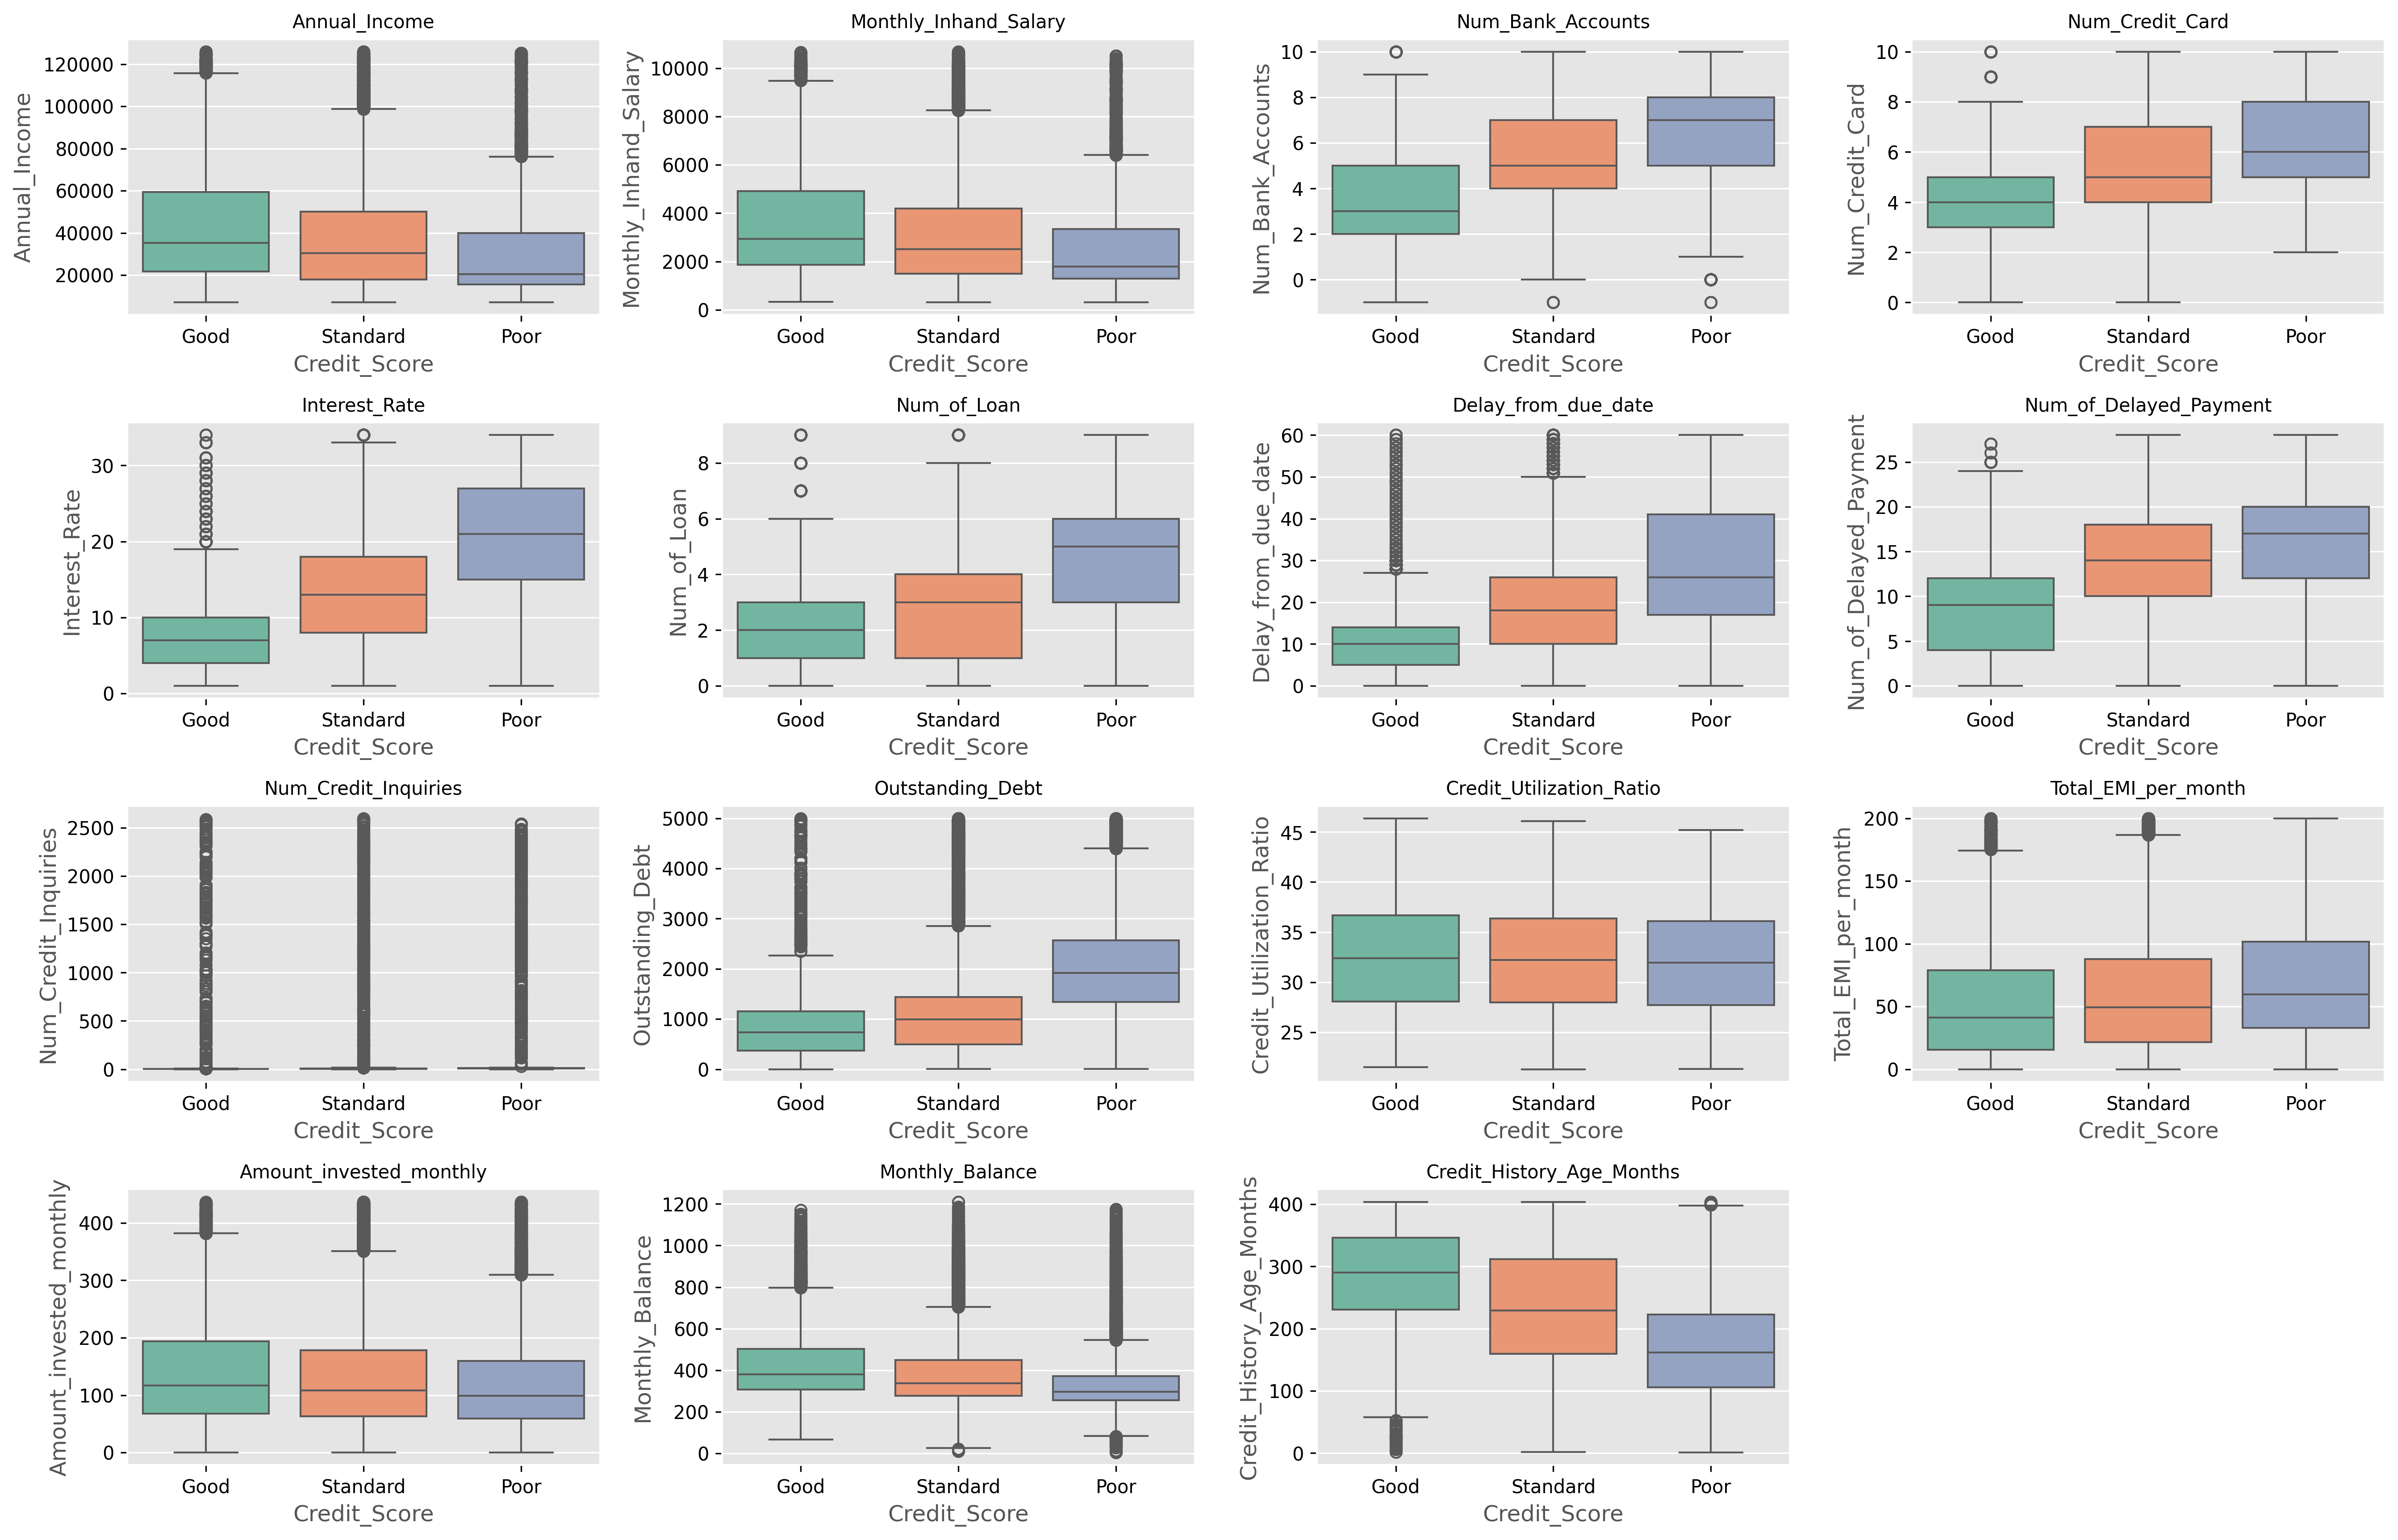

In [ ]:
plot_boxplot_num_cols(df_train)

A correlation matrix of the numerical features was analyzed to identify and remove highly correlated features.

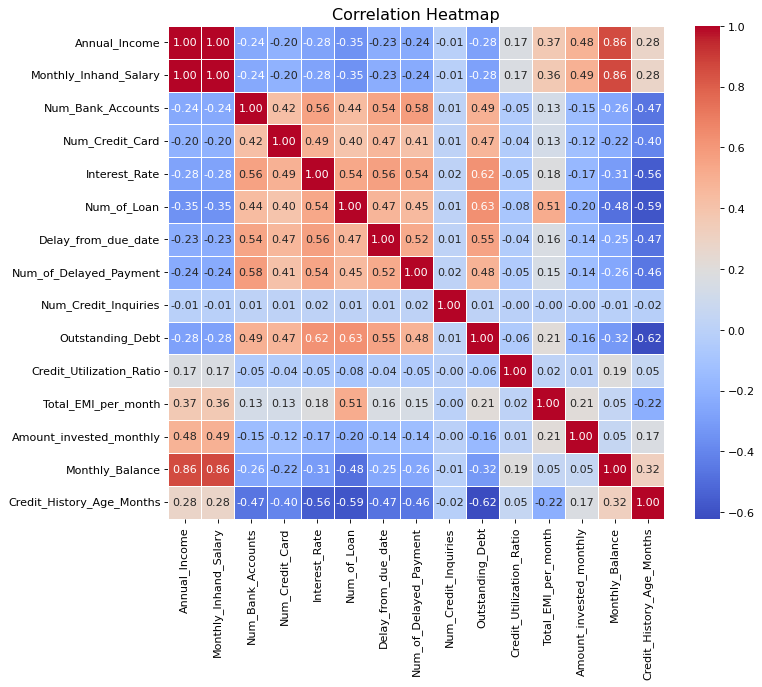

In [ ]:
numeric_df = df_train.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Drop unwanted columns
columns_to_drop = ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_History_Age', 'Type_of_Loan', 'Occupation', 'Monthly_Inhand_Salary']
columns_to_drop_existing = [col for col in columns_to_drop if col in df_train.columns]
df_train = df_train.drop(columns=columns_to_drop_existing)

df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63730 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Annual_Income              63730 non-null  float64
 1   Num_Bank_Accounts          63730 non-null  int64  
 2   Num_Credit_Card            63730 non-null  int64  
 3   Interest_Rate              63730 non-null  int64  
 4   Num_of_Loan                63730 non-null  int64  
 5   Delay_from_due_date        63730 non-null  int64  
 6   Num_of_Delayed_Payment     63730 non-null  float64
 7   Credit_Mix                 63730 non-null  object 
 8   Outstanding_Debt           63730 non-null  float64
 9   Credit_Utilization_Ratio   63730 non-null  float64
 10  Payment_of_Min_Amount      63730 non-null  object 
 11  Total_EMI_per_month        63730 non-null  float64
 12  Amount_invested_monthly    63730 non-null  float64
 13  Payment_Behaviour          63730 non-null  object 


Bar plots were created for categorical features against credit scores to analyze trends and relationships.

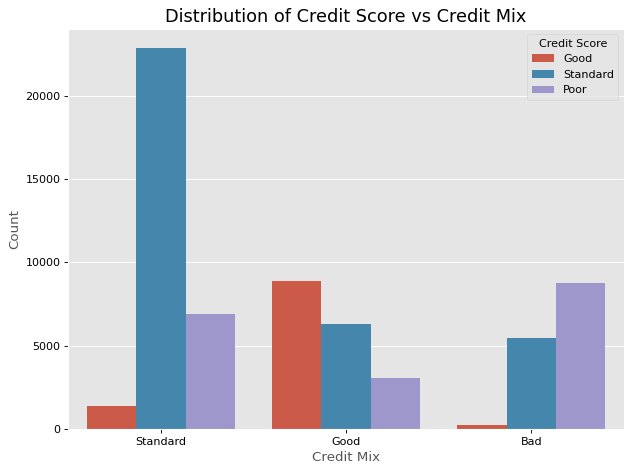

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_train, x='Credit_Mix', hue='Credit_Score', order=df_train['Credit_Mix'].value_counts().index)

plt.title('Distribution of Credit Score vs Credit Mix', fontsize=16)
plt.xlabel('Credit Mix', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Credit Score', fontsize=10)
plt.tight_layout()
plt.show()

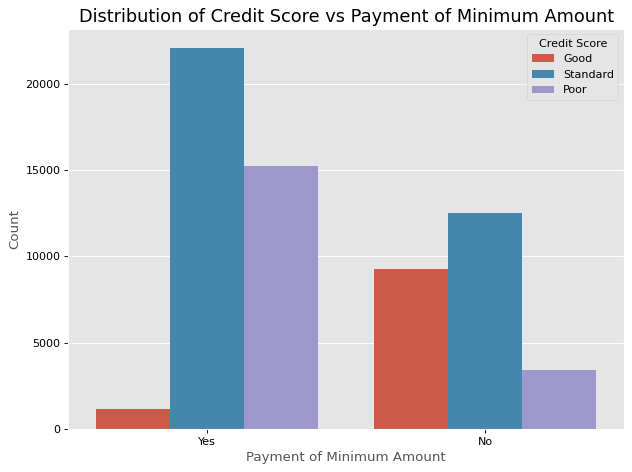

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_train, x='Payment_of_Min_Amount', hue='Credit_Score', order=df_train['Payment_of_Min_Amount'].value_counts().index)

plt.title('Distribution of Credit Score vs Payment of Minimum Amount', fontsize=16)
plt.xlabel('Payment of Minimum Amount', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Credit Score', fontsize=10)
plt.tight_layout()
plt.show()

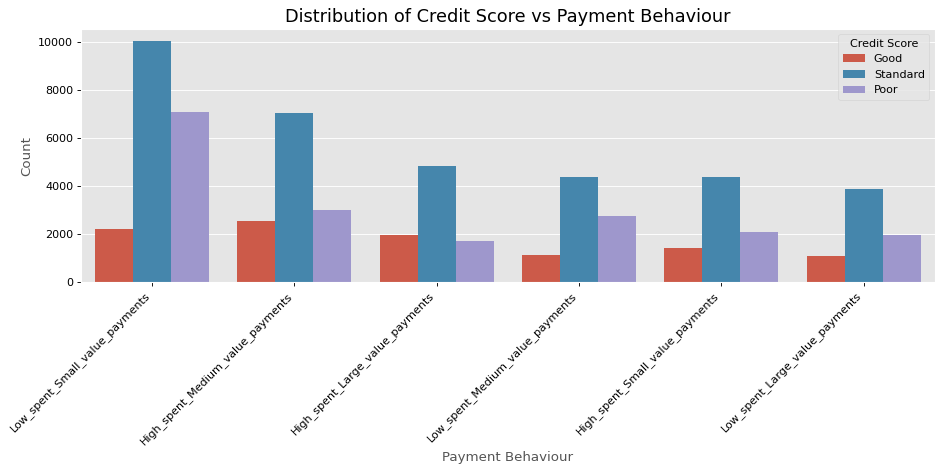

In [ ]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df_train, x='Payment_Behaviour', hue='Credit_Score', order=df_train['Payment_Behaviour'].value_counts().index)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Distribution of Credit Score vs Payment Behaviour', fontsize=16)
plt.xlabel('Payment Behaviour', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Credit Score', fontsize=10)
plt.tight_layout()
plt.show()

Encoding categorical variables

In [ ]:
credit_mix_mapping = {
    'Bad': 0,
    'Standard': 1,
    'Good': 2
}
df_train['Credit_Mix'] = df_train['Credit_Mix'].map(credit_mix_mapping)

payment_mapping = {
    'No': 0,
    'Yes': 1
}
df_train['Payment_of_Min_Amount'] = df_train['Payment_of_Min_Amount'].map(payment_mapping)

payment_behaviour_mapping = {
    'Low_spent_Small_value_payments': 1,
    'Low_spent_Medium_value_payments': 2,
    'Low_spent_Large_value_payments': 3,
    'High_spent_Small_value_payments': 4,
    'High_spent_Medium_value_payments': 5,
    'High_spent_Large_value_payments': 6
}
df_train['Payment_Behaviour'] = df_train['Payment_Behaviour'].map(payment_behaviour_mapping)

credit_score_mapping = {
    'Good': 2,
    'Standard': 1,
    'Poor': 0
}
df_train['Credit_Score'] = df_train['Credit_Score'].map(credit_score_mapping)

In [ ]:
X = df_train.drop('Credit_Score', axis=1)
y = df_train['Credit_Score']

Multi-collinearity was assessed, and variables with high VIF values were removed to ensure model stability and interpretability.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                      feature         VIF
0               Annual_Income  143.933326
1           Num_Bank_Accounts   11.161692
2             Num_Credit_Card   12.296141
3               Interest_Rate    9.360448
4                 Num_of_Loan   11.172586
5         Delay_from_due_date    6.215668
6      Num_of_Delayed_Payment   12.378186
7                  Credit_Mix   15.134929
8            Outstanding_Debt    6.325666
9    Credit_Utilization_Ratio   38.906879
10      Payment_of_Min_Amount    6.060398
11        Total_EMI_per_month   13.583955
12    Amount_invested_monthly   25.794399
13          Payment_Behaviour    7.560290
14            Monthly_Balance  181.552136
15  Credit_History_Age_Months   11.873830


In [ ]:
# Drop highly correlated columns
columns_to_drop = ['Monthly_Balance', 'Credit_Utilization_Ratio']
columns_to_drop_existing = [col for col in columns_to_drop if col in df_train.columns]
df_train = df_train.drop(columns=columns_to_drop_existing)

In [ ]:
X = df_train.drop('Credit_Score', axis=1)
y = df_train['Credit_Score']

In [ ]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                      feature        VIF
0               Annual_Income   9.203534
1           Num_Bank_Accounts  10.501590
2             Num_Credit_Card  11.740059
3               Interest_Rate   9.069926
4                 Num_of_Loan  10.707337
5         Delay_from_due_date   6.113606
6      Num_of_Delayed_Payment  10.991898
7                  Credit_Mix   7.864422
8            Outstanding_Debt   6.146783
9       Payment_of_Min_Amount   5.494948
10        Total_EMI_per_month   6.657745
11    Amount_invested_monthly   5.943698
12          Payment_Behaviour   7.275511
13  Credit_History_Age_Months  10.274748


In [ ]:
mi_scores = mutual_info_classif(X, y)

for i, score in enumerate(mi_scores):
    print(f"Feature '{X.columns[i]}': Mutual Information Score = {score}")

Feature 'Annual_Income': Mutual Information Score = 0.603449340100586
Feature 'Num_Bank_Accounts': Mutual Information Score = 0.09831466953687173
Feature 'Num_Credit_Card': Mutual Information Score = 0.11057758898403236
Feature 'Interest_Rate': Mutual Information Score = 0.177854702772541
Feature 'Num_of_Loan': Mutual Information Score = 0.08087658572920664
Feature 'Delay_from_due_date': Mutual Information Score = 0.11560355113262832
Feature 'Num_of_Delayed_Payment': Mutual Information Score = 0.08854312898130368
Feature 'Credit_Mix': Mutual Information Score = 0.19517118897104235
Feature 'Outstanding_Debt': Mutual Information Score = 0.5990624256868078
Feature 'Payment_of_Min_Amount': Mutual Information Score = 0.12535825419318147
Feature 'Total_EMI_per_month': Mutual Information Score = 0.5380777098367968
Feature 'Amount_invested_monthly': Mutual Information Score = 0.0
Feature 'Payment_Behaviour': Mutual Information Score = 0.015902609487044028
Feature 'Credit_History_Age_Months': M

In [ ]:
sorted_mi_scores = sorted(zip(X.columns, mi_scores), key=lambda x: x[1], reverse=True)
sorted_columns = [x[0] for x in sorted_mi_scores]
sorted_scores = [x[1] for x in sorted_mi_scores]

colorscale = 'Viridis'

fig = go.Figure(data=[go.Bar(x=sorted_columns, y=sorted_scores, marker=dict(color=sorted_scores, colorbar=dict(title='Mutual Information Score', len=0.5, y=0.2)))])

fig.update_layout(title='Mutual Information Scores for Each Feature',
                  xaxis_title='Features',
                  yaxis_title='Mutual Information Score')

fig.show()

*   Even before modeling, the mutual Information Score graphs gives out a good idea about what features affect the credit score risk rating more



##Model Building

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

* One of the classes in Credit Score is undersampled which was making the models very biased and lowered the accuracy as well, hence using SMOTE technique to balance out the class distribution


In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(Counter(y_resampled))

Counter({2: 34614, 1: 34614, 0: 34614})


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=77)

###Random Forest

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

baseline_prediction = y_train.mean()
baseline_mse = mean_squared_error(y_test, [baseline_prediction] * len(y_test))
print("Baseline MSE:", baseline_mse)
print("MSE RFRegressor", mse)

print("Accuracy on training set:", model.score(X_train, y_train))
print("Accuracy on testing set:", model.score(X_test, y_test))

Mean Squared Error: 0.1477225307354027
Baseline MSE: 0.6624136744544161
MSE RFRegressor 0.1477225307354027
Accuracy on training set: 0.9999862427602526
Accuracy on testing set: 0.877507784162039


Feature Importance:
                       Feature  Importance
8            Outstanding_Debt    0.132824
3               Interest_Rate    0.107247
7                  Credit_Mix    0.103384
13  Credit_History_Age_Months    0.096427
5         Delay_from_due_date    0.079811
0               Annual_Income    0.067659
11    Amount_invested_monthly    0.067637
6      Num_of_Delayed_Payment    0.067111
9       Payment_of_Min_Amount    0.065982
10        Total_EMI_per_month    0.057044
1           Num_Bank_Accounts    0.047871
2             Num_Credit_Card    0.045718
4                 Num_of_Loan    0.032273
12          Payment_Behaviour    0.029012


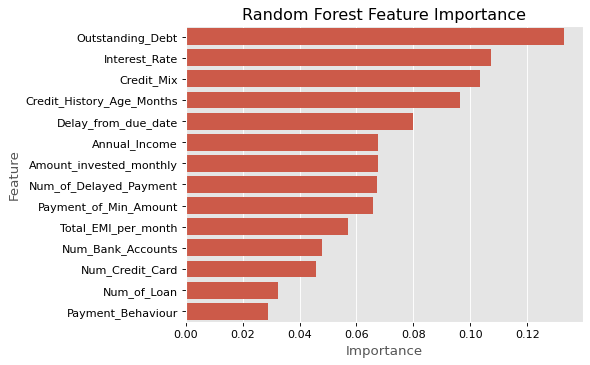

In [ ]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:\n", feature_importance)
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Random Forest Feature Importance')
plt.show()

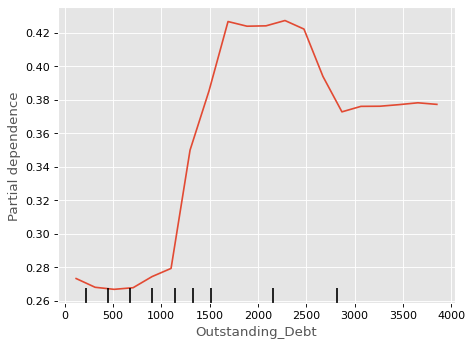

In [ ]:
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=['Outstanding_Debt'],
    target=0,
    kind='average',
    grid_resolution=20,
)
plt.show()

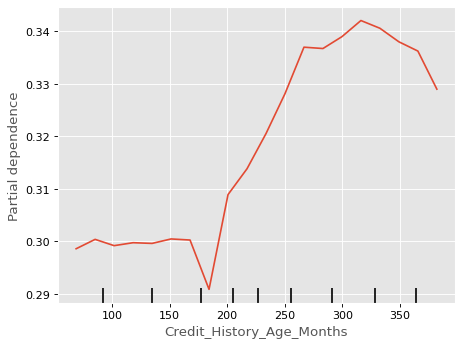

In [ ]:
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=['Credit_History_Age_Months'],
    target=2,
    kind='average',
    grid_resolution=20,
)
plt.show()

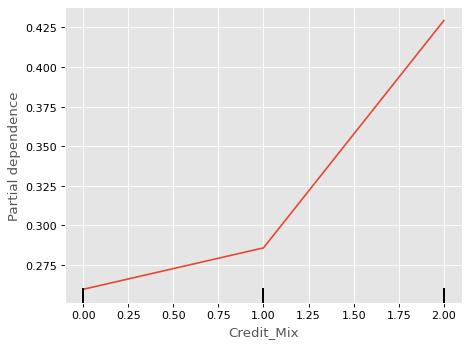

In [ ]:
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=['Credit_Mix'],
    target=2,
    kind='average',
    grid_resolution=20,
)
plt.show()

Plotting the partial dependency plots to understand whether the impact of each feature on the target variable aligns with expectations and to identify any interesting thresholds or significant changes in behavior.

###Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(
    criterion='gini',         # Split criterion ('gini' for Gini Impurity, 'entropy' for Information Gain)
    max_depth=None,           # Limit tree depth (None means grow until all leaves are pure)
    random_state=42,          # For reproducibility
    class_weight='balanced'   # Handle imbalanced data
)

# Train the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred = dt_model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.82
Confusion Matrix:
 [[8526 1571  257]
 [1541 7852 1124]
 [ 250  942 9090]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.82     10354
           1       0.76      0.75      0.75     10517
           2       0.87      0.88      0.88     10282

    accuracy                           0.82     31153
   macro avg       0.82      0.82      0.82     31153
weighted avg       0.82      0.82      0.82     31153



Feature Importance:
                       Feature  Importance
7                  Credit_Mix    0.206871
8            Outstanding_Debt    0.193657
13  Credit_History_Age_Months    0.100844
11    Amount_invested_monthly    0.070348
3               Interest_Rate    0.069482
0               Annual_Income    0.068804
6      Num_of_Delayed_Payment    0.056540
5         Delay_from_due_date    0.055783
10        Total_EMI_per_month    0.054389
1           Num_Bank_Accounts    0.038409
2             Num_Credit_Card    0.032043
12          Payment_Behaviour    0.023795
4                 Num_of_Loan    0.019666
9       Payment_of_Min_Amount    0.009369


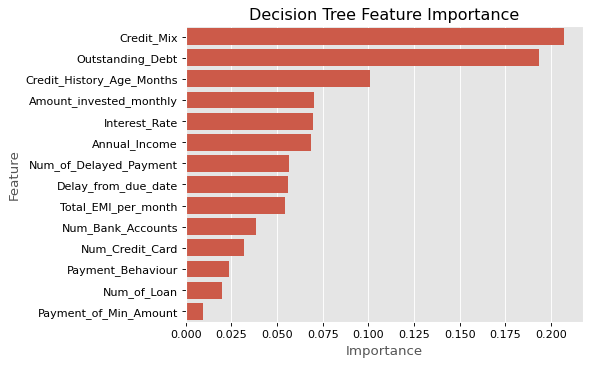

In [ ]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:\n", feature_importance)

# Plot feature importance
import seaborn as sns

sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Decision Tree Feature Importance')
plt.show()

###Logistic regression


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Create and train the logistic regression model
log_model = LogisticRegression(
    solver='lbfgs',         # Default solver
    max_iter=1000,          # Number of iterations
    random_state=42,
    class_weight='balanced' # Handle class imbalance
)
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# Predict on the test set
y_pred = log_model.predict(X_test)

# Predict probabilities (optional)
y_prob = log_model.predict_proba(X_test)

Accuracy: 0.66
Confusion Matrix:
 [[3681  991  935]
 [2250 6265 1869]
 [  66  393 2669]]


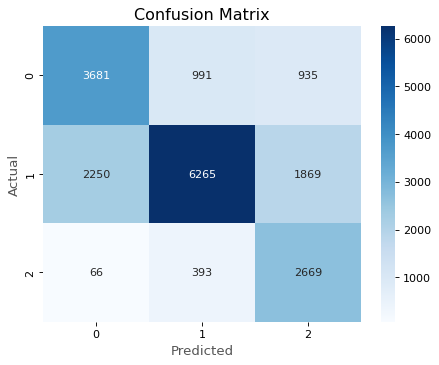

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.66      0.63      5607
           1       0.82      0.60      0.69     10384
           2       0.49      0.85      0.62      3128

    accuracy                           0.66     19119
   macro avg       0.64      0.70      0.65     19119
weighted avg       0.70      0.66      0.66     19119



In [ ]:
# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Visualization of Confusion Matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# **VEHICLE INSURANCE**

In [ ]:
data4 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Group_Project_704/AutoInsurance.csv')
data4

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,Location Code,Marital Status,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,Suburban,Married,69,32,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,Suburban,Single,94,13,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,Suburban,Married,108,18,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,Suburban,Married,106,18,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,3/2/2011,Employed,M,43836,Rural,Single,73,12,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9129,LA72316,California,23405.987980,No,Basic,Bachelor,10/2/2011,Employed,M,71941,Urban,Married,73,18,89,0,2,Personal Auto,Personal L1,Offer2,Web,198.234764,Four-Door Car,Medsize
9130,PK87824,California,3096.511217,Yes,Extended,College,12/2/2011,Employed,F,21604,Suburban,Divorced,79,14,28,0,1,Corporate Auto,Corporate L3,Offer1,Branch,379.200000,Four-Door Car,Medsize
9131,TD14365,California,8163.890428,No,Extended,Bachelor,6/2/2011,Unemployed,M,0,Suburban,Single,85,9,37,3,2,Corporate Auto,Corporate L2,Offer1,Branch,790.784983,Four-Door Car,Medsize
9132,UP19263,California,7524.442436,No,Extended,College,3/2/2011,Employed,M,21941,Suburban,Married,96,34,3,0,3,Personal Auto,Personal L2,Offer3,Branch,691.200000,Four-Door Car,Large


Encoding and printing an encodement map for guidance

In [ ]:
data4_c = data4.copy()
data4_c.drop(columns=['Customer', 'State', 'Effective To Date'], inplace=True)
#Dictionary to store the mappings for each categorical column
category_mappings = {}

for col in data4_c.columns:
    if data4_c[col].dtype == 'object':
        #Convert column to category and store the mapping
        data4_c[col] = data4_c[col].astype('category')
        category_mappings[col] = dict(enumerate(data4_c[col].cat.categories))
        #apply the encoding
        data4_c[col] = data4_c[col].cat.codes

print("\nEncodement mappings for categorical columns:")
for col, mapping in category_mappings.items():
    print(f"\nColumn: {col}")
    for code, category in mapping.items():
        print(f"  {code} -> {category}")



Encodement mappings for categorical columns:

Column: Response
  0 -> No
  1 -> Yes

Column: Coverage
  0 -> Basic
  1 -> Extended
  2 -> Premium

Column: Education
  0 -> Bachelor
  1 -> College
  2 -> Doctor
  3 -> High School or Below
  4 -> Master

Column: EmploymentStatus
  0 -> Disabled
  1 -> Employed
  2 -> Medical Leave
  3 -> Retired
  4 -> Unemployed

Column: Gender
  0 -> F
  1 -> M

Column: Location Code
  0 -> Rural
  1 -> Suburban
  2 -> Urban

Column: Marital Status
  0 -> Divorced
  1 -> Married
  2 -> Single

Column: Policy Type
  0 -> Corporate Auto
  1 -> Personal Auto
  2 -> Special Auto

Column: Policy
  0 -> Corporate L1
  1 -> Corporate L2
  2 -> Corporate L3
  3 -> Personal L1
  4 -> Personal L2
  5 -> Personal L3
  6 -> Special L1
  7 -> Special L2
  8 -> Special L3

Column: Renew Offer Type
  0 -> Offer1
  1 -> Offer2
  2 -> Offer3
  3 -> Offer4

Column: Sales Channel
  0 -> Agent
  1 -> Branch
  2 -> Call Center
  3 -> Web

Column: Vehicle Class
  0 -> Four

In [ ]:
data4_c.columns

Index(['Customer Lifetime Value', 'Response', 'Coverage', 'Education',
       'EmploymentStatus', 'Gender', 'Income', 'Location Code',
       'Marital Status', 'Monthly Premium Auto', 'Months Since Last Claim',
       'Months Since Policy Inception', 'Number of Open Complaints',
       'Number of Policies', 'Policy Type', 'Policy', 'Renew Offer Type',
       'Sales Channel', 'Total Claim Amount', 'Vehicle Class', 'Vehicle Size'],
      dtype='object')

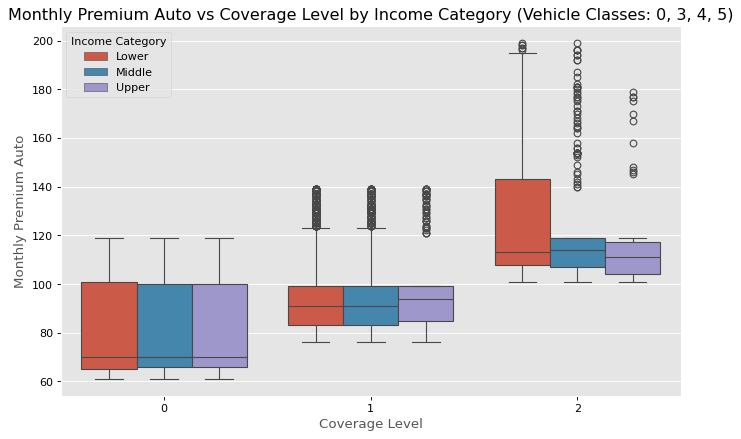

In [ ]:
data4_c['income_category'] = pd.cut(data4_c['Income'], bins=[0, 50000, 85000, 200000], labels=['Lower', 'Middle', 'Upper'])
# Filtering data for vehicle classes 0, 3, and 4, 5
subset_data = data4_c[data4_c['Vehicle Class'].isin([0, 3, 4, 5])]

# Creating the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=subset_data, x='Coverage', y='Monthly Premium Auto', hue='income_category')
plt.title("Monthly Premium Auto vs Coverage Level by Income Category (Vehicle Classes: 0, 3, 4, 5)")
plt.xlabel("Coverage Level")
plt.ylabel("Monthly Premium Auto")
plt.legend(title="Income Category")
plt.show()


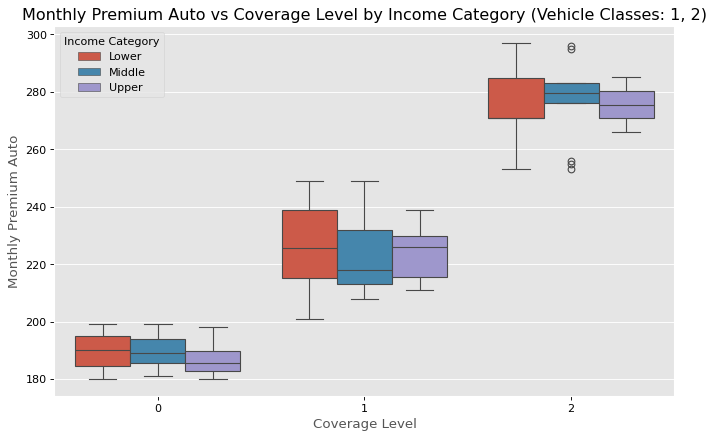

In [ ]:
# Filtering data for vehicle classes 1 and 2
subset_data = data4_c[data4_c['Vehicle Class'].isin([1, 2])]

# Creating the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=subset_data, x='Coverage', y='Monthly Premium Auto', hue='income_category')
plt.title("Monthly Premium Auto vs Coverage Level by Income Category (Vehicle Classes: 1, 2)")
plt.xlabel("Coverage Level")
plt.ylabel("Monthly Premium Auto")
plt.legend(title="Income Category")
plt.show()

data4_c.drop(columns=['income_category'], inplace=True)

## **Cleaning**

In [ ]:
# Split data into features (X) and target (y)
X = data4_c.drop('Monthly Premium Auto', axis=1)
X=sm.add_constant(X)
y = data4_c['Monthly Premium Auto']

# Split into training and testing sets
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
def multicol(X, threshold=10):
    while True:
        # Calculate VIF for each feature
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

        #highest VIF
        high_vif = vif_data[vif_data['VIF'] > threshold].sort_values(by='VIF', ascending=False)

        #break loop
        if high_vif.empty:
            break

        drop_feature = high_vif.iloc[0]['feature']
        X = X.drop(columns=[drop_feature])
        print(f"Dropped {drop_feature} with VIF {high_vif.iloc[0]['VIF']}")

    return X

X = multicol(X)

X

Dropped const with VIF 43.06030771563387
Dropped Policy with VIF 27.06466967307288


,Customer Lifetime Value,Response,Coverage,Education,EmploymentStatus,Gender,Income,Location Code,Marital Status,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,2763.519279,0,0,0,1,0,56274,1,1,32,5,0,1,0,0,0,384.811147,5,1
1,6979.535903,0,1,0,4,0,0,1,2,13,42,0,8,1,2,0,1131.464935,0,1
2,12887.431650,0,2,0,1,0,48767,1,1,18,38,0,2,1,0,0,566.472247,5,1
3,7645.861827,0,0,0,4,1,0,1,1,18,65,0,7,0,0,2,529.881344,3,1
4,2813.692575,0,0,0,1,1,43836,0,2,12,44,0,1,1,0,0,138.130879,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9129,23405.987980,0,0,0,1,1,71941,2,1,18,89,0,2,1,1,3,198.234764,0,1
9130,3096.511217,1,1,1,1,0,21604,1,0,14,28,0,1,0,0,1,379.200000,0,1
9131,8163.890428,0,1,0,4,1,0,1,2,9,37,3,2,0,0,1,790.784983,0,1
9132,7524.442436,0,1,1,1,1,21941,1,1,34,3,0,3,1,2,1,691.200000,0,0


In [ ]:
def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(train_X[variables], train_y)
    return model

def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(train_y, [train_y.mean()] * len(train_y), model, df=1)
    return AIC_score(train_y, model.predict(train_X[variables]), model)

best_model, best_variables = stepwise_selection(train_X.columns, train_model, score_model, verbose=True)

X = data4_c[best_variables]

X

Variables: const, Customer Lifetime Value, Response, Coverage, Education, EmploymentStatus, Gender, Income, Location Code, Marital Status, Months Since Last Claim, Months Since Policy Inception, Number of Open Complaints, Number of Policies, Policy Type, Policy, Renew Offer Type, Sales Channel, Total Claim Amount, Vehicle Class, Vehicle Size
Start: score=72562.76, constant
Step: score=68754.76, add Total Claim Amount
Step: score=67688.59, add Coverage
Step: score=66919.39, add Customer Lifetime Value
Step: score=66444.83, add Income
Step: score=66111.24, add Location Code
Step: score=65960.22, add Vehicle Class
Step: score=65878.45, add EmploymentStatus
Step: score=65826.43, add Marital Status
Step: score=65808.94, add Vehicle Size
Step: score=65794.30, add Gender
Step: score=65789.43, add Months Since Policy Inception
Step: score=65785.68, add Renew Offer Type
Step: score=65782.62, add Response
Step: score=65782.62, unchanged None


,Total Claim Amount,Coverage,Customer Lifetime Value,Income,Location Code,Vehicle Class,EmploymentStatus,Marital Status,Vehicle Size,Gender,Months Since Policy Inception,Renew Offer Type,Response
0,384.811147,0,2763.519279,56274,1,5,1,1,1,0,5,0,0
1,1131.464935,1,6979.535903,0,1,0,4,2,1,0,42,2,0
2,566.472247,2,12887.431650,48767,1,5,1,1,1,0,38,0,0
3,529.881344,0,7645.861827,0,1,3,4,1,1,1,65,0,0
4,138.130879,0,2813.692575,43836,0,0,1,2,1,1,44,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9129,198.234764,0,23405.987980,71941,2,0,1,1,1,1,89,1,0
9130,379.200000,1,3096.511217,21604,1,0,1,0,1,0,28,0,1
9131,790.784983,1,8163.890428,0,1,0,4,2,1,1,37,0,0
9132,691.200000,1,7524.442436,21941,1,0,1,1,0,1,3,2,0


In [ ]:
columns_to_keep = list(X.columns) + ['Monthly Premium Auto']
data4_c = data4_c[columns_to_keep]

<Axes: >

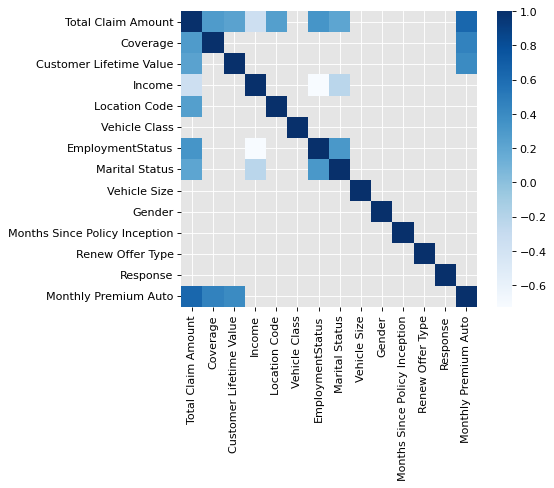

In [ ]:
corrmat = data4_c.corr()
sns.heatmap(corrmat[abs(corrmat)>0.2], square = True, cmap="Blues")

## **Model**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.25, random_state=7)

# Bagging: Decide the parameters for the new Decision Tree with ensemble
dtvehicle_bag=RandomForestRegressor(max_features=13, random_state=23) # Bagging is special case of RF, when we use all features (13 in this case).

# Random forest: Decide the parameters for the new Decision Tree with ensemble
dtvehicle_RF=RandomForestRegressor(max_features=2, random_state=23)

# Boosting: Decide the parameters for the new Decision Tree with ensemble
dtvehicle_boost=GradientBoostingRegressor(n_estimators=500, learning_rate=0.01, random_state=23) # Learning rate shrinks the contribution of each tree by learning_rate.

# Fit the bagging model on training data
# Since we are using the training portion of the data, we are now "training" our model.
dtvehicle_bag.fit(X_train, Y_train)

# Fit the random forest model on training data
# Since we are using the training portion of the data, we are now "training" our model.
dtvehicle_RF.fit(X_train, Y_train)

# Fit the boosting model on training data
# Since we are using the training portion of the data, we are now "training" our model.
dtvehicle_boost.fit(X_train, Y_train)

# Now, get the predicted values and evaluate the training of the new decision tree models:
DTbag_predictions_tr=dtvehicle_bag.predict(X_train) # predictions for training set

# Now, get the predicted values and evaluate the training of the new decision tree models:
DTRF_predictions_tr=dtvehicle_RF.predict(X_train) # predictions for training set

# Now, get the predicted values and evaluate the training of the new decision tree models:
DTboost_predictions_tr=dtvehicle_boost.predict(X_train) # predictions for training set

# How good is this prediction of bagging in training?
regressionSummary(Y_train, DTbag_predictions_tr)

# How good is this prediction of random forest in training?
regressionSummary(Y_train, DTRF_predictions_tr)

# How good is this prediction of random forest in training?
regressionSummary(Y_train,DTboost_predictions_tr)


Regression statistics

                      Mean Error (ME) : -0.0175
       Root Mean Squared Error (RMSE) : 1.3756
            Mean Absolute Error (MAE) : 0.7158
          Mean Percentage Error (MPE) : -0.0657
Mean Absolute Percentage Error (MAPE) : 0.7287

Regression statistics

                      Mean Error (ME) : 0.0332
       Root Mean Squared Error (RMSE) : 3.3487
            Mean Absolute Error (MAE) : 1.8501
          Mean Percentage Error (MPE) : -0.4554
Mean Absolute Percentage Error (MAPE) : 1.8735

Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 7.7669
            Mean Absolute Error (MAE) : 4.9731
          Mean Percentage Error (MPE) : -0.8421
Mean Absolute Percentage Error (MAPE) : 5.2087


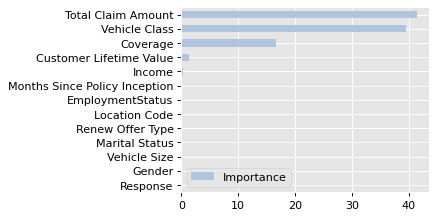

In [ ]:
Importance = pd.DataFrame({'Importance':dtvehicle_bag.feature_importances_*100}, \
                          index=best_variables)
Importance.sort_values('Importance', axis=0, ascending=True).plot(kind='barh', color='lightsteelblue', ) # kind='barh' : Horizontal bar
plt.gcf().set_size_inches(4, 3)

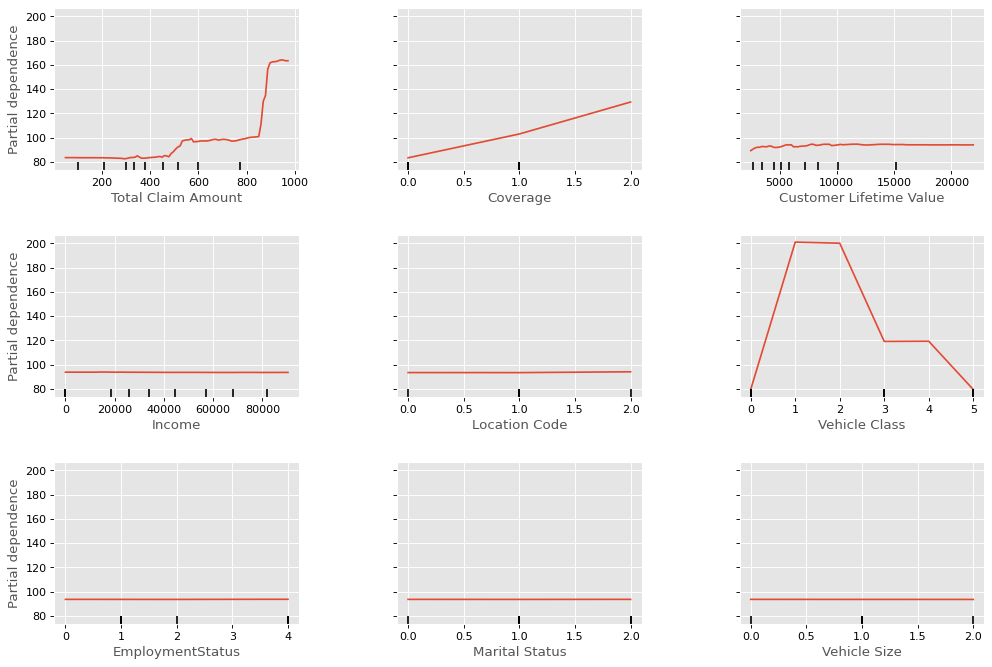

In [ ]:
features = [0, 1, 2, 3, 4, 5, 6, 7, 8]

fig, ax = plt.subplots(3, 3, figsize=(15, 10))  # Adjust figure size for better spacing
PartialDependenceDisplay.from_estimator(dtvehicle_bag, X_train, features, ax=ax)

plt.subplots_adjust(hspace=0.4, wspace=0.4)  # Increase spacing vertically (hspace) and horizontally (wspace)

plt.show()

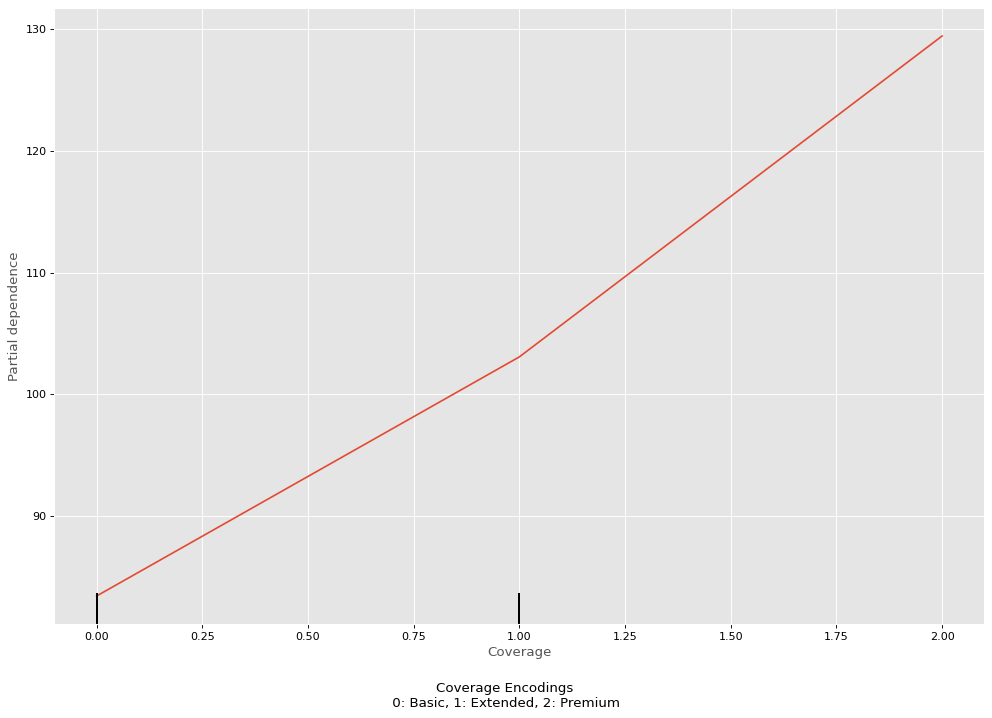

In [ ]:
features = [1]

fig, ax = plt.subplots(1, 1, figsize=(15, 10))  # Adjust figure size for better spacing
PartialDependenceDisplay.from_estimator(dtvehicle_bag, X_train, features, ax=ax)

legend_text = "Coverage Encodings\n 0: Basic, 1: Extended, 2: Premium"
plt.gcf().text(0.5, 0.02, legend_text, fontsize=12, ha='center', va='center')

plt.subplots_adjust(hspace=0.8, wspace=0.4)  # Increase spacing vertically (hspace) and horizontally (wspace)

plt.show()

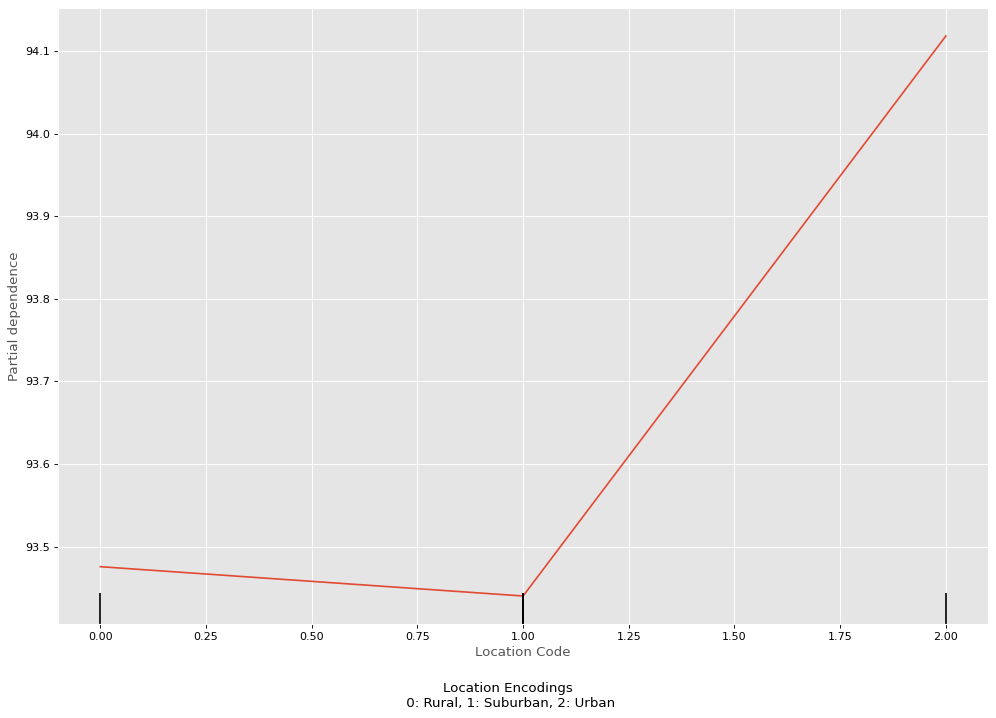

In [ ]:
features = [4]

fig, ax = plt.subplots(1, 1, figsize=(15, 10))  # Adjust figure size for better spacing
PartialDependenceDisplay.from_estimator(dtvehicle_bag, X_train, features, ax=ax)

legend_text = "Location Encodings\n 0: Rural, 1: Suburban, 2: Urban"
plt.gcf().text(0.5, 0.02, legend_text, fontsize=12, ha='center', va='center')

plt.subplots_adjust(hspace=0.8, wspace=0.4)  # Increase spacing vertically (hspace) and horizontally (wspace)

plt.show()

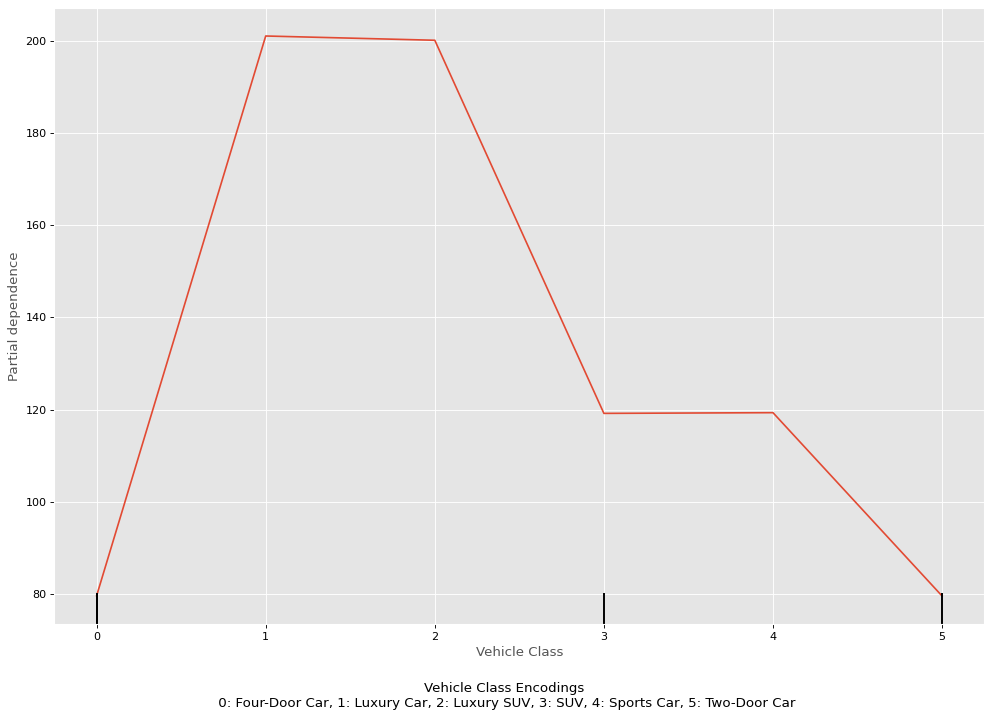

In [ ]:
features = [5]

fig, ax = plt.subplots(1, 1, figsize=(15, 10))  # Adjust figure size for better spacing
PartialDependenceDisplay.from_estimator(dtvehicle_bag, X_train, features, ax=ax)

legend_text = "Vehicle Class Encodings\n 0: Four-Door Car, 1: Luxury Car, 2: Luxury SUV, 3: SUV, 4: Sports Car, 5: Two-Door Car"
plt.gcf().text(0.5, 0.02, legend_text, fontsize=12, ha='center', va='center')

plt.subplots_adjust(hspace=0.8, wspace=0.4)  # Increase spacing vertically (hspace) and horizontally (wspace)

plt.show()

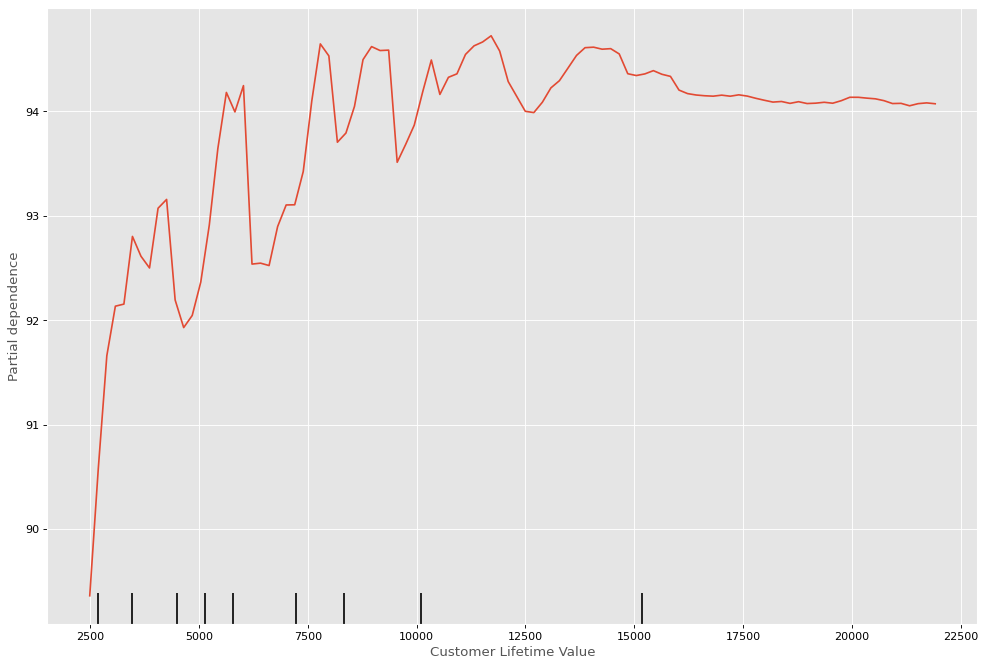

In [ ]:
features = [2]

fig, ax = plt.subplots(1, 1, figsize=(15, 10))  # Adjust figure size for better spacing
PartialDependenceDisplay.from_estimator(dtvehicle_bag, X_train, features, ax=ax)

plt.subplots_adjust(hspace=0.4, wspace=0.4)  # Increase spacing vertically (hspace) and horizontally (wspace)

plt.show()

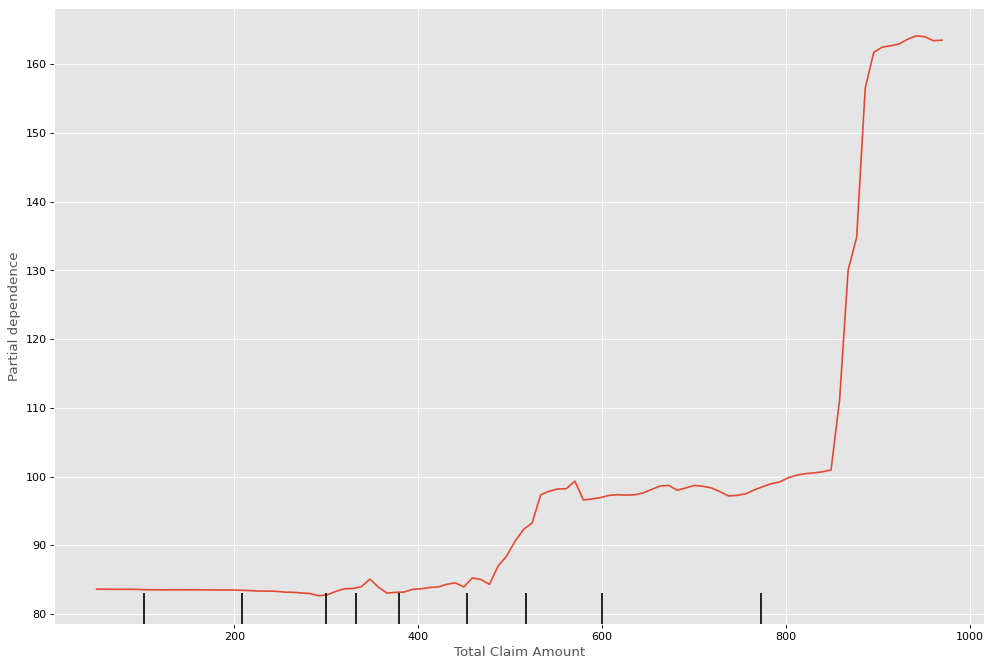

In [ ]:
features = [0]

fig, ax = plt.subplots(1, 1, figsize=(15, 10))  # Adjust figure size for better spacing
PartialDependenceDisplay.from_estimator(dtvehicle_bag, X_train, features, ax=ax)

plt.subplots_adjust(hspace=0.4, wspace=0.4)  # Increase spacing vertically (hspace) and horizontally (wspace)

plt.show()


Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 6.5629
            Mean Absolute Error (MAE) : 4.7093
          Mean Percentage Error (MPE) : -0.3875
Mean Absolute Percentage Error (MAPE) : 4.9754

Regression statistics

                      Mean Error (ME) : 0.1223
       Root Mean Squared Error (RMSE) : 6.5836
            Mean Absolute Error (MAE) : 4.5482
          Mean Percentage Error (MPE) : -0.2525
Mean Absolute Percentage Error (MAPE) : 4.8374


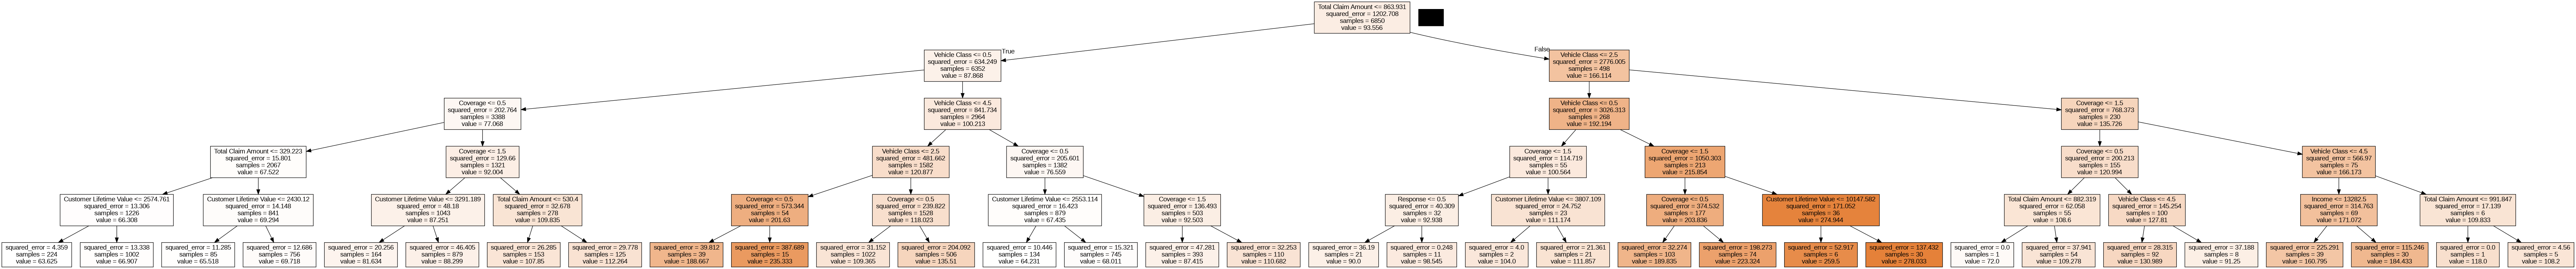

In [ ]:
decision_tree = DecisionTreeRegressor(max_depth=5, random_state=42)  # Use DecisionTreeClassifier for classification tasks

# Fit the model
decision_tree.fit(X_train, Y_train)

# Predict on the training set and summarize
Y_train_pred = decision_tree.predict(X_train)
regressionSummary(Y_train, Y_train_pred)  # Use classificationSummary for classifiers

# Predict on the testing set and summarize
Y_test_pred = decision_tree.predict(X_test)
regressionSummary(Y_test, Y_test_pred)  # Use classificationSummary for classifiers

# Visualize the decision tree
plotDecisionTree(decision_tree, feature_names=X.columns, rotate=True)
plt.show()

# For more detailed visualization with Graphviz
from sklearn.tree import export_graphviz
from IPython.display import Image
import pydotplus as pplus
from six import StringIO

# Generate the decision tree graph
dot_data = StringIO()
export_graphviz(decision_tree, out_file=dot_data, feature_names=X.columns, filled=True)
graph = pplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [ ]:
n_train = len(Y_train)  # Number of samples in the training set
n_test = len(Y_test)    # Number of samples in the test set
k = X_train.shape[1]    # Number of predictors (features)

# Train performance
train_r2 = r2_score(Y_train, Y_train_pred)
train_rmse = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
train_adj_r2 = 1 - (1 - train_r2) * ((n_train - 1) / (n_train - k - 1))

# Test performance
test_r2 = r2_score(Y_test, Y_test_pred)
test_rmse = np.sqrt(mean_squared_error(Y_test, Y_test_pred))
test_adj_r2 = 1 - (1 - test_r2) * ((n_test - 1) / (n_test - k - 1))

# Print performance metrics
print(f"Training R-squared: {train_r2:.2f}")
print(f"Training Adjusted R-squared: {train_adj_r2:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")

print(f"Test R-squared: {test_r2:.2f}")
print(f"Test Adjusted R-squared: {test_adj_r2:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")

Training R-squared: 0.96
Training Adjusted R-squared: 0.96
Training RMSE: 6.56
Test R-squared: 0.96
Test Adjusted R-squared: 0.96
Test RMSE: 6.58


The model shows a mean RMSE of 8.54, with an adjusted r^2 value of 0.96. The mean of monthly premiums being 93.2, the model is doing quite well at predicting the monthly premiums that will be paid.

In [ ]:
from sklearn.model_selection import KFold, cross_validate
import numpy as np

# Define the K-Fold cross-validation parameters
cvparam = KFold(n_splits=3, random_state=13, shuffle=True)

# Perform cross-validation
scores_mse = cross_validate(
    decision_tree,                # Your trained model
    X_train,                      # Features for training
    Y_train,                      # Target variable
    cv=cvparam,                   # Cross-validation splitting strategy
    scoring='neg_mean_squared_error'  # Use MSE (negated for compatibility)
)

# Extract test scores (negative MSE) and print fold-wise results
cv_test_scores = -scores_mse['test_score']
print(f"Fold-wise test scores (MSE): {cv_test_scores}")

# Calculate RMSE for each fold and overall mean RMSE
fold_rmse = np.sqrt(cv_test_scores)
mean_rmse = np.mean(fold_rmse)

print(f"Fold-wise test scores (RMSE): {fold_rmse}")
print(f"Mean RMSE across folds: {mean_rmse:.2f}")


Fold-wise test scores (MSE): [ 44.68641829 140.60669911  49.91199123]
Fold-wise test scores (RMSE): [ 6.68479007 11.85776957  7.06484191]
Mean RMSE across folds: 8.54


In [ ]:
data4_c['Monthly Premium Auto'].describe()

,Monthly Premium Auto
count,9134.000000
mean,93.219291
std,34.407967
min,61.000000
25%,68.000000
50%,83.000000
75%,109.000000
max,298.000000


Another visualization to show the combinations that yield the lowest and highest premium charges. The highest charges on average are experienced by those driving luxury 4 door cars with a premium coverage, an average income of around 80000, and about 17 months since policy inception. Lowest are for regular 4 door car drivers with basic coverage, an average income of 55000, and about 48 months since policy inception. Customer lifetime values differ a lot, being 24000 and 5663, respectively. And finally, The premium chagres on the high average are ate 298, whereas for the lower end it's just at 67 on average.

In [ ]:
# Aggregate the data to calculate mean charges, mean age, mean BMI, and other relevant metrics for each group
grouped_data = data4_c.groupby(
    ['Vehicle Class', 'Coverage', 'Location Code'], as_index=False
).agg({
    'Monthly Premium Auto': 'mean',  # Replaced Monthly Premium Auto with Monthly Premium Auto
    'Customer Lifetime Value': 'mean',
    'Income': 'mean',
    'Months Since Policy Inception': 'mean'
})

# Find the bar with the highest and lowest Monthly Premium Auto
highest_premium_row = grouped_data.loc[grouped_data['Monthly Premium Auto'].idxmax()]
lowest_premium_row = grouped_data.loc[grouped_data['Monthly Premium Auto'].idxmin()]

print("Bar with Highest Monthly Premium Auto:")
print(highest_premium_row)

print("\nBar with Lowest Monthly Premium Auto:")
print(lowest_premium_row)

# Create a bar plot with Customer Lifetime Value (CLV) represented by color
fig = px.bar(
    grouped_data,
    x='Vehicle Class',
    y='Monthly Premium Auto',  # Use Monthly Premium Auto as y-axis
    color='Customer Lifetime Value',  # Use CLV for the color scale
    facet_row='Coverage',
    facet_col='Location Code',
    title='Average Monthly Premium Auto by Vehicle Class, Coverage, and Location Code',
    facet_col_wrap=2,  # Wrap columns for better visualization if many panels
)

fig.update_yaxes(title_text='')

# Update axis labels and colorbar for readability
fig.update_layout(
    xaxis_title="Vehicle Class",
    coloraxis_colorbar=dict(title="Average Customer Lifetime Value"),
    title_font_size=16
)

# Show the plot
fig.show()


Bar with Highest Monthly Premium Auto:
Vehicle Class                        1.00000
Coverage                             2.00000
Location Code                        0.00000
Monthly Premium Auto               296.00000
Customer Lifetime Value          23984.62144
Income                           79655.00000
Months Since Policy Inception       17.00000
Name: 15, dtype: float64

Bar with Lowest Monthly Premium Auto:
Vehicle Class                        0.000000
Coverage                             0.000000
Location Code                        0.000000
Monthly Premium Auto                67.221441
Customer Lifetime Value           5663.238679
Income                           55047.947276
Months Since Policy Inception       48.391916
Name: 0, dtype: float64
